# 소주제 2 — 일일 판매량 예측 (Regression)

> **목표:** 제품 속성과 재고 정보를 기반으로 **Avg_Daily_Sales(일일 평균 판매량)**를 예측하는 회귀 모델을 구축하고, 판매량에 가장 큰 영향을 미치는 요인을 SHAP 등으로 해석한다.

---

| 항목 | 내용 |
|------|------|
| **프로젝트** | 머신러닝 기반 식료품 유통 재고 관리 최적화 시스템 |
| **담당** | 이현아 |
| **데이터** | Inventory Management E-Grocery (1,000행 × 37열) |
| **모델** | Linear Regression, Ridge, Lasso, Random Forest, XGBoost |
| **평가 지표** | RMSE, MAE, R² Score |

### 도출할 인사이트

1. 제품 속성과 재고 정보만으로 일일 판매량을 어느 정도 정확하게 예측할 수 있는가?
2. 판매량에 가장 큰 영향을 미치는 변수(피처)는 무엇인가?
3. 카테고리(10종)별, ABC 등급별 판매량 패턴은 어떻게 다른가?
4. 데이터 누수(Data Leakage) 피처를 제거했을 때 모델 성능이 어떻게 변하는가?
5. SHAP 분석 결과, 각 피처가 판매량 예측에 미치는 방향(+/-)과 크기는?
6. 입고월(Received_Month)에 따른 판매량의 계절성 패턴이 존재하는가?
7. ★ Order_Frequency_per_month는 준누수(Quasi-Leakage)인가, 강한 예측 변수인가?
8. ★ Learning Curve를 통해 과적합의 원인은 데이터 부족인가, 모델 복잡도인가?
9. ★ Permutation Importance로 Impurity 편향을 검증했을 때 순위 변화가 있는가?

In [1]:
# ========================================
# 0. 라이브러리 임포트 & 설정
# ========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import warnings
import os
import csv
import json
import joblib
import shap

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

# 한글 폰트 설정 — Malgun Gothic (matplotlib 내장 폰트 디렉토리에 사전 설치됨)
fm._load_fontmanager(try_read_cache=False)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 150
sns.set_style('whitegrid')
sns.set_palette('Set2')
plt.rcParams['font.family'] = 'Malgun Gothic'  # whitegrid 적용 후 재설정

# 경고 숨김 & 시드 고정
warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)

# 출력 디렉토리 설정
BASE_DIR = os.path.dirname(os.path.abspath('__file__'))
FIG_DIR = os.path.join(BASE_DIR, '..', 'outputs', 'figures')
MODEL_DIR = os.path.join(BASE_DIR, '..', 'outputs', 'models')
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

print('✅ 라이브러리 및 설정 완료')
print(f'   한글 폰트: {plt.rcParams["font.family"]}')
_test_font = fm.findfont('Malgun Gothic')
print(f'   폰트 경로: {_test_font}')
print(f'   저장 경로 (figures): {os.path.abspath(FIG_DIR)}')
print(f'   저장 경로 (models) : {os.path.abspath(MODEL_DIR)}')

Matplotlib is building the font cache; this may take a moment.


✅ 라이브러리 및 설정 완료
   한글 폰트: ['Malgun Gothic']
   폰트 경로: /opt/anaconda3/lib/python3.13/site-packages/matplotlib/mpl-data/fonts/ttf/malgun.ttf
   저장 경로 (figures): /Volumes/Corsair EX300U Media/00_work_out/02_ing/Phase8_mini/outputs/figures
   저장 경로 (models) : /Volumes/Corsair EX300U Media/00_work_out/02_ing/Phase8_mini/outputs/models


---
## 1. 데이터 로드 & 기본 확인

In [2]:
# ========================================
# 1. 데이터 로드 & 기본 확인
# ========================================
DATA_PATH = os.path.join(BASE_DIR, '..', 'data',
                         'Supply Chain Inventory Management Grocery Industry',
                         'Inventory Management E-Grocery - InventoryData.csv')
CSV_PATH = os.path.abspath(DATA_PATH)
df_raw = pd.read_csv(CSV_PATH)

print(f'📊 데이터 Shape: {df_raw.shape}')
print(f'   행: {df_raw.shape[0]:,}개, 열: {df_raw.shape[1]}개')
print()
print('--- df.info() ---')
df_raw.info()

📊 데이터 Shape: (1000, 37)
   행: 1,000개, 열: 37개

--- df.info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 37 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   SKU_ID                        1000 non-null   object 
 1   SKU_Name                      1000 non-null   object 
 2   Category                      1000 non-null   object 
 3   ABC_Class                     1000 non-null   object 
 4   Supplier_ID                   1000 non-null   object 
 5   Supplier_Name                 1000 non-null   object 
 6   Warehouse_ID                  1000 non-null   object 
 7   Warehouse_Location            1000 non-null   object 
 8   Batch_ID                      1000 non-null   object 
 9   Received_Date                 1000 non-null   object 
 10  Last_Purchase_Date            1000 non-null   object 
 11  Expiry_Date                   1000 non-null   object 
 12 

In [3]:
# 결측치 확인
print('=== 결측치 확인 ===')
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(1)
missing_df = pd.DataFrame({'결측치 수': missing, '비율(%)': missing_pct})
print(missing_df[missing_df['결측치 수'] > 0].to_string())
print(f'\n→ Notes 컬럼만 {missing["Notes"]}건 결측 (분석 미사용). 실질적 결측치 이슈 없음.')

=== 결측치 확인 ===
       결측치 수  비율(%)
Notes    834   83.4

→ Notes 컬럼만 834건 결측 (분석 미사용). 실질적 결측치 이슈 없음.


In [4]:
# Avg_Daily_Sales (타겟) 기초 통계 — 전처리 전 원본 확인
print('=== 타겟 변수 (Avg_Daily_Sales) 원본 형태 ===')
print(f'   dtype: {df_raw["Avg_Daily_Sales"].dtype}')
print(f'   샘플: {df_raw["Avg_Daily_Sales"].head(5).tolist()}')
print(f'   → 인도네시아 로케일: 쉼표(,)가 소수점으로 사용됨')

=== 타겟 변수 (Avg_Daily_Sales) 원본 형태 ===
   dtype: object
   샘플: ['28,57', '34,99', '36,55', '25,49', '17,05']
   → 인도네시아 로케일: 쉼표(,)가 소수점으로 사용됨


---
## 2. 데이터 전처리

> **인도네시아 로케일 주의:**
> - 쉼표(`,`)가 **소수점**, 마침표(`.`)가 **천단위 구분자**
> - 금액: `$2.084,25` = $2,084.25
> - 일부 컬럼에 천단위+소수점 **혼합값** 존재 (예: SKU_Churn_Rate `2.142,90`)
> - `Reorder_Point`: pandas가 `1.170`을 1.17로 오파싱 (실제 1170) — 10건

In [5]:
# ========================================
# 2-1. 인도네시아 로케일 숫자 변환
# ========================================
df = df_raw.copy()

# object 타입 쉼표 소수점 컬럼 — 천단위 마침표 먼저 제거 후 쉼표→마침표
# ⚠️ 단순 str.replace(',', '.')만 하면 '2.142,90' 같은 혼합값에서 ValueError 발생!
comma_decimal_cols = [
    'Avg_Daily_Sales', 'Days_of_Inventory',
    'SKU_Churn_Rate', 'Order_Frequency_per_month'
]
for col in comma_decimal_cols:
    df[col] = (df[col].astype(str)
               .str.replace('.', '', regex=False)   # 천단위 구분 마침표 제거
               .str.replace(',', '.', regex=False)   # 쉼표 소수점 → 마침표
               .astype(float))

print('✅ 인도네시아 로케일 숫자 변환 완료')
for col in comma_decimal_cols:
    print(f'   {col}: min={df[col].min():.2f}, max={df[col].max():.2f}, mean={df[col].mean():.2f}')

✅ 인도네시아 로케일 숫자 변환 완료
   Avg_Daily_Sales: min=1.01, max=99.50, mean=26.58
   Days_of_Inventory: min=0.00, max=21.95, mean=9.99
   SKU_Churn_Rate: min=1.37, max=2142.90, mean=6.33
   Order_Frequency_per_month: min=1.00, max=46.00, mean=9.81


In [6]:
# ========================================
# 2-2. Reorder_Point 천단위 오파싱 수정 (10건)
# ========================================
# pandas가 CSV의 '1.170'을 float 1.17로 읽음 (실제 의미: 1170)
# → raw CSV에서 문자열 재추출하여 수정

raw_rp = []
with open(CSV_PATH) as f:
    reader = csv.DictReader(f)
    for row in reader:
        raw_rp.append(row['Reorder_Point'])

# 마침표 포함 값 = 천단위 구분자 → 제거 후 정수 변환
fix_count = 0
rp_fixed = []
for val in raw_rp:
    if '.' in val:
        rp_fixed.append(int(val.replace('.', '')))
        fix_count += 1
    else:
        rp_fixed.append(int(val))
df['Reorder_Point'] = rp_fixed

print(f'✅ Reorder_Point 수정 완료: {fix_count}건')
print(f'   수정 전 예시: 1.170 (pandas: 1.17) → 수정 후: 1170')
print(f'   범위: {df["Reorder_Point"].min()} ~ {df["Reorder_Point"].max()}')

✅ Reorder_Point 수정 완료: 10건
   수정 전 예시: 1.170 (pandas: 1.17) → 수정 후: 1170
   범위: 3 ~ 1870


In [7]:
# ========================================
# 2-3. 금액 컬럼 변환
# ========================================
money_cols = ['Unit_Cost_USD', 'Last_Purchase_Price_USD', 'Total_Inventory_Value_USD']
for col in money_cols:
    df[col] = (df[col].astype(str)
               .str.replace('$', '', regex=False)
               .str.replace('.', '', regex=False)
               .str.replace(',', '.', regex=False)
               .astype(float))

print('✅ 금액 컬럼 변환 완료')
print(f'   Unit_Cost_USD: ${df["Unit_Cost_USD"].min():.2f} ~ ${df["Unit_Cost_USD"].max():.2f}')

# 퍼센트 컬럼 변환 (소주제2 미사용이지만 공통 전처리)
pct_cols = ['Supplier_OnTime_Pct', 'Audit_Variance_Pct', 'Demand_Forecast_Accuracy_Pct']
for col in pct_cols:
    df[col] = (df[col].astype(str)
               .str.replace('%', '', regex=False)
               .str.replace(',', '.', regex=False)
               .astype(float))

print('✅ 퍼센트 컬럼 변환 완료')

✅ 금액 컬럼 변환 완료
   Unit_Cost_USD: $0.29 ~ $24.90
✅ 퍼센트 컬럼 변환 완료


In [8]:
# ========================================
# 2-4. 날짜 컬럼 파싱 & 파생변수
# ========================================
for col in ['Received_Date', 'Last_Purchase_Date', 'Expiry_Date', 'Audit_Date']:
    df[col] = pd.to_datetime(df[col])

# 소주제 2 전용 파생변수: Received_Month (계절성 분석)
df['Received_Month'] = df['Received_Date'].dt.month

print('✅ 날짜 파싱 & 파생변수 생성 완료')
print(f'   Received_Month 분포: {sorted(df["Received_Month"].unique())}')
print(f'   범위: {df["Received_Month"].min()}월 ~ {df["Received_Month"].max()}월')

✅ 날짜 파싱 & 파생변수 생성 완료
   Received_Month 분포: [np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9)]
   범위: 3월 ~ 9월


In [9]:
# ========================================
# 2-5. 전처리 결과 검증
# ========================================
print('=== 전처리 후 타겟 변수 (Avg_Daily_Sales) 통계 ===')
ads = df['Avg_Daily_Sales']
stats = {
    '건수': len(ads),
    '평균': f'{ads.mean():.2f}',
    '표준편차': f'{ads.std():.2f}',
    '최솟값': f'{ads.min():.2f}',
    '25%': f'{ads.quantile(0.25):.2f}',
    '중앙값': f'{ads.median():.2f}',
    '75%': f'{ads.quantile(0.75):.2f}',
    '최댓값': f'{ads.max():.2f}',
    '왜도(Skewness)': f'{ads.skew():.4f}',
    '첨도(Kurtosis)': f'{ads.kurt():.4f}'
}
for k, v in stats.items():
    print(f'   {k}: {v}')
print(f'\n→ 왜도 {ads.skew():.2f} > 0: 오른쪽으로 꼬리가 긴 분포 (저판매량 제품 다수)')

=== 전처리 후 타겟 변수 (Avg_Daily_Sales) 통계 ===
   건수: 1000
   평균: 26.58
   표준편차: 21.25
   최솟값: 1.01
   25%: 10.73
   중앙값: 20.23
   75%: 36.59
   최댓값: 99.50
   왜도(Skewness): 1.2292
   첨도(Kurtosis): 0.9751

→ 왜도 1.23 > 0: 오른쪽으로 꼬리가 긴 분포 (저판매량 제품 다수)


---
## 3. EDA (탐색적 데이터 분석)

### 3.1 타겟 변수 분포

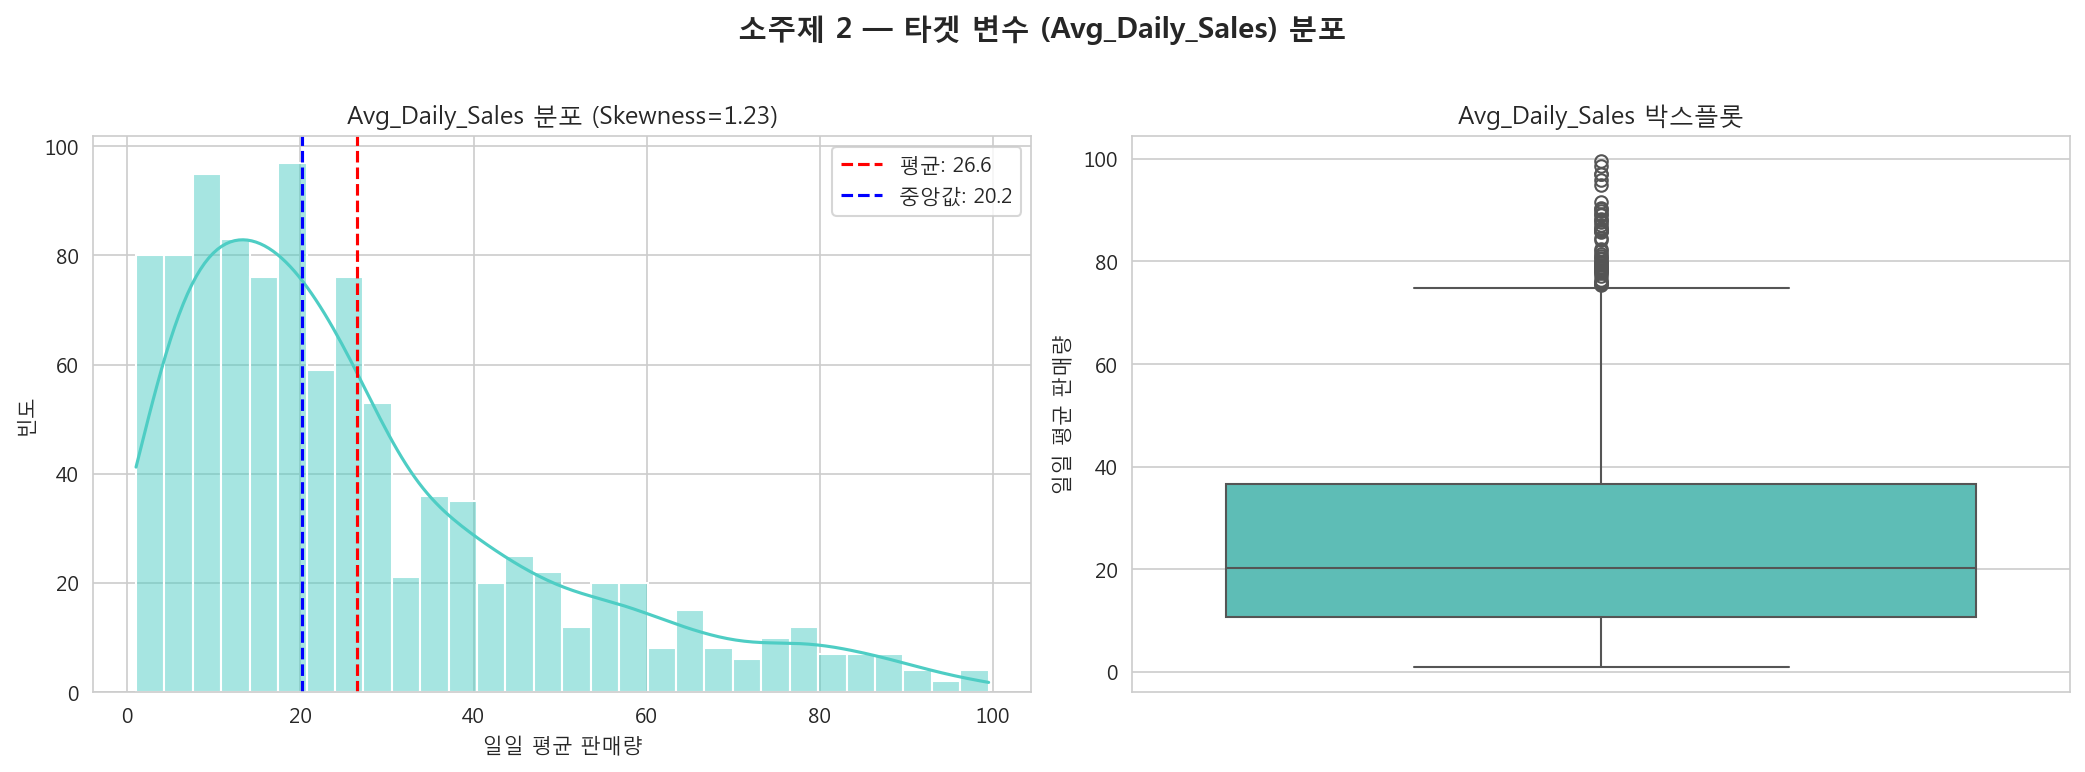

✅ 저장: eda_target_distribution_s2.png


In [10]:
# ========================================
# 3.1 타겟 변수(Avg_Daily_Sales) 분포
# ========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 히스토그램 + KDE
sns.histplot(df['Avg_Daily_Sales'], bins=30, kde=True, color='#4ECDC4', ax=axes[0])
axes[0].axvline(df['Avg_Daily_Sales'].mean(), color='red', linestyle='--', linewidth=1.5, label=f'평균: {df["Avg_Daily_Sales"].mean():.1f}')
axes[0].axvline(df['Avg_Daily_Sales'].median(), color='blue', linestyle='--', linewidth=1.5, label=f'중앙값: {df["Avg_Daily_Sales"].median():.1f}')
axes[0].set_title(f'Avg_Daily_Sales 분포 (Skewness={df["Avg_Daily_Sales"].skew():.2f})')
axes[0].set_xlabel('일일 평균 판매량')
axes[0].set_ylabel('빈도')
axes[0].legend()

# 박스플롯
sns.boxplot(y=df['Avg_Daily_Sales'], color='#4ECDC4', ax=axes[1])
axes[1].set_title('Avg_Daily_Sales 박스플롯')
axes[1].set_ylabel('일일 평균 판매량')

plt.suptitle('소주제 2 — 타겟 변수 (Avg_Daily_Sales) 분포', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'eda_target_distribution_s2.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ 저장: eda_target_distribution_s2.png')

### 3.2 카테고리별 판매량 분포

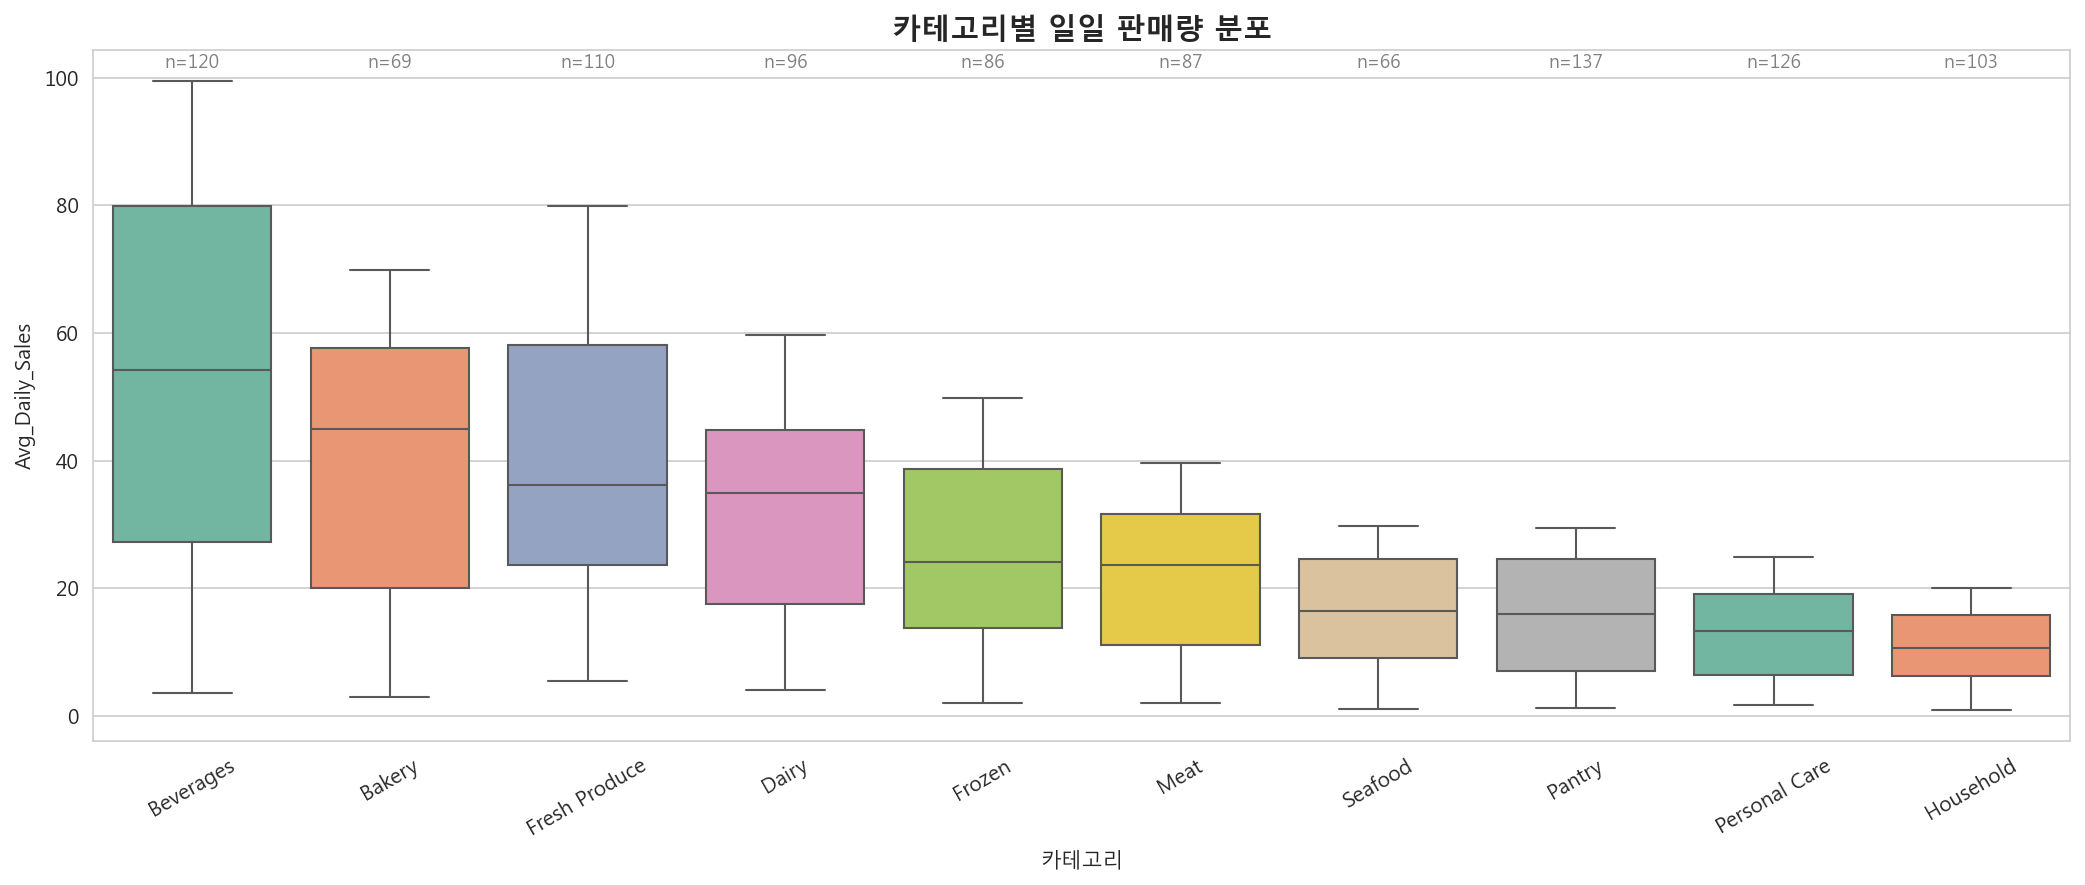

=== 카테고리별 Avg_Daily_Sales 통계 ===
                건수     평균    중앙값   표준편차
Category                               
Beverages      120  53.09  54.28  29.04
Fresh Produce  110  39.81  36.16  21.76
Bakery          69  39.28  45.01  20.51
Dairy           96  31.67  34.93  16.41
Frozen          86  25.64  24.18  14.23
Meat            87  21.66  23.58  11.69
Seafood         66  16.54  16.47   8.93
Pantry         137  15.58  15.92   8.80
Personal Care  126  12.97  13.28   6.88
Household      103  10.98  10.67   5.75


In [11]:
# ========================================
# 3.2 카테고리별 판매량 분포
# ========================================
fig, ax = plt.subplots(figsize=(14, 6))

# 중앙값 기준 정렬
cat_order = df.groupby('Category')['Avg_Daily_Sales'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Category', y='Avg_Daily_Sales', order=cat_order,
            palette='Set2', ax=ax)
ax.set_title('카테고리별 일일 판매량 분포', fontsize=14, fontweight='bold')
ax.set_xlabel('카테고리')
ax.set_ylabel('Avg_Daily_Sales')
ax.tick_params(axis='x', rotation=30)

# 카테고리별 건수 표시
for i, cat in enumerate(cat_order):
    n = (df['Category'] == cat).sum()
    med = df[df['Category'] == cat]['Avg_Daily_Sales'].median()
    ax.text(i, df['Avg_Daily_Sales'].max() * 1.02, f'n={n}', ha='center', fontsize=9, color='gray')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'eda_category_sales_boxplot_s2.png'), dpi=150, bbox_inches='tight')
plt.show()

# 카테고리별 통계
cat_stats = df.groupby('Category')['Avg_Daily_Sales'].agg(['count', 'mean', 'median', 'std']).round(2)
cat_stats.columns = ['건수', '평균', '중앙값', '표준편차']
print('=== 카테고리별 Avg_Daily_Sales 통계 ===')
print(cat_stats.sort_values('평균', ascending=False).to_string())

### 3.3 ABC 등급별 판매량 분포

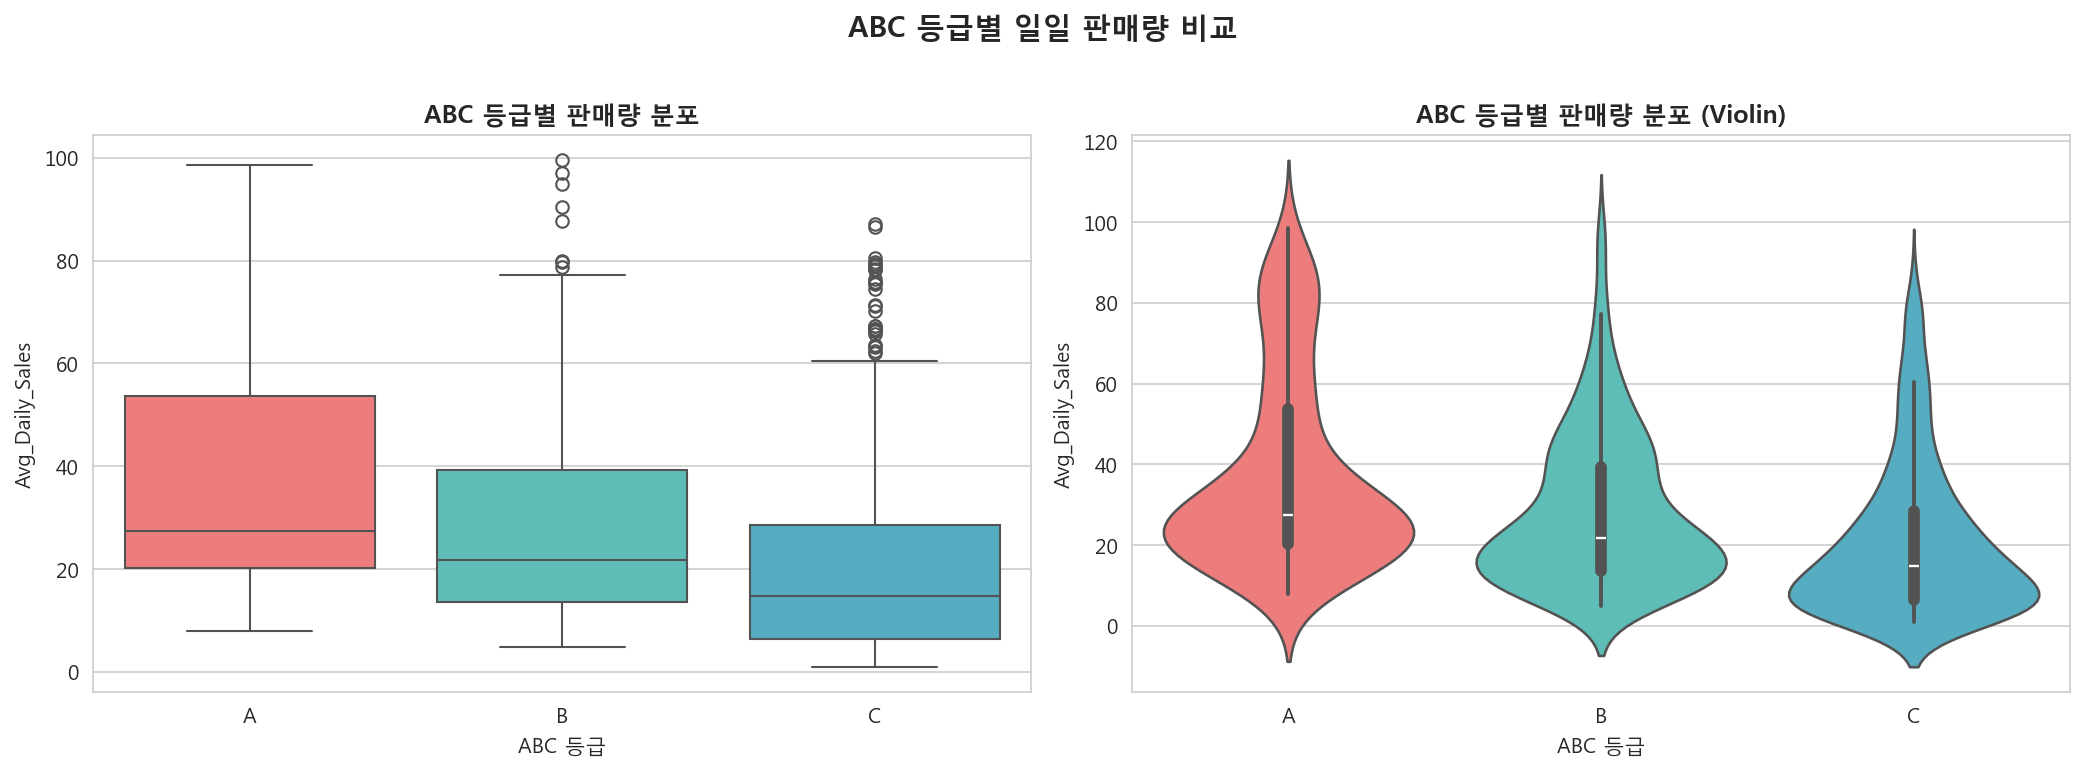

=== ABC 등급별 Avg_Daily_Sales 통계 ===
            건수     평균    중앙값   표준편차
ABC_Class                          
A          200  37.69  27.46  24.04
B          300  28.49  21.84  19.17
C          500  21.00  14.84  19.25


In [12]:
# ========================================
# 3.3 ABC 등급별 판매량 분포
# ========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 박스플롯
sns.boxplot(data=df, x='ABC_Class', y='Avg_Daily_Sales', order=['A', 'B', 'C'],
            palette=['#FF6B6B', '#4ECDC4', '#45B7D1'], ax=axes[0])
axes[0].set_title('ABC 등급별 판매량 분포', fontweight='bold')
axes[0].set_xlabel('ABC 등급')
axes[0].set_ylabel('Avg_Daily_Sales')

# 바이올린플롯
sns.violinplot(data=df, x='ABC_Class', y='Avg_Daily_Sales', order=['A', 'B', 'C'],
               palette=['#FF6B6B', '#4ECDC4', '#45B7D1'], ax=axes[1], inner='box')
axes[1].set_title('ABC 등급별 판매량 분포 (Violin)', fontweight='bold')
axes[1].set_xlabel('ABC 등급')
axes[1].set_ylabel('Avg_Daily_Sales')

plt.suptitle('ABC 등급별 일일 판매량 비교', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'eda_abc_sales_boxplot_s2.png'), dpi=150, bbox_inches='tight')
plt.show()

# ABC별 통계
abc_stats = df.groupby('ABC_Class')['Avg_Daily_Sales'].agg(['count', 'mean', 'median', 'std']).round(2)
abc_stats.columns = ['건수', '평균', '중앙값', '표준편차']
print('=== ABC 등급별 Avg_Daily_Sales 통계 ===')
print(abc_stats.loc[['A', 'B', 'C']].to_string())

### 3.4 수치형 피처 vs Avg_Daily_Sales 산점도

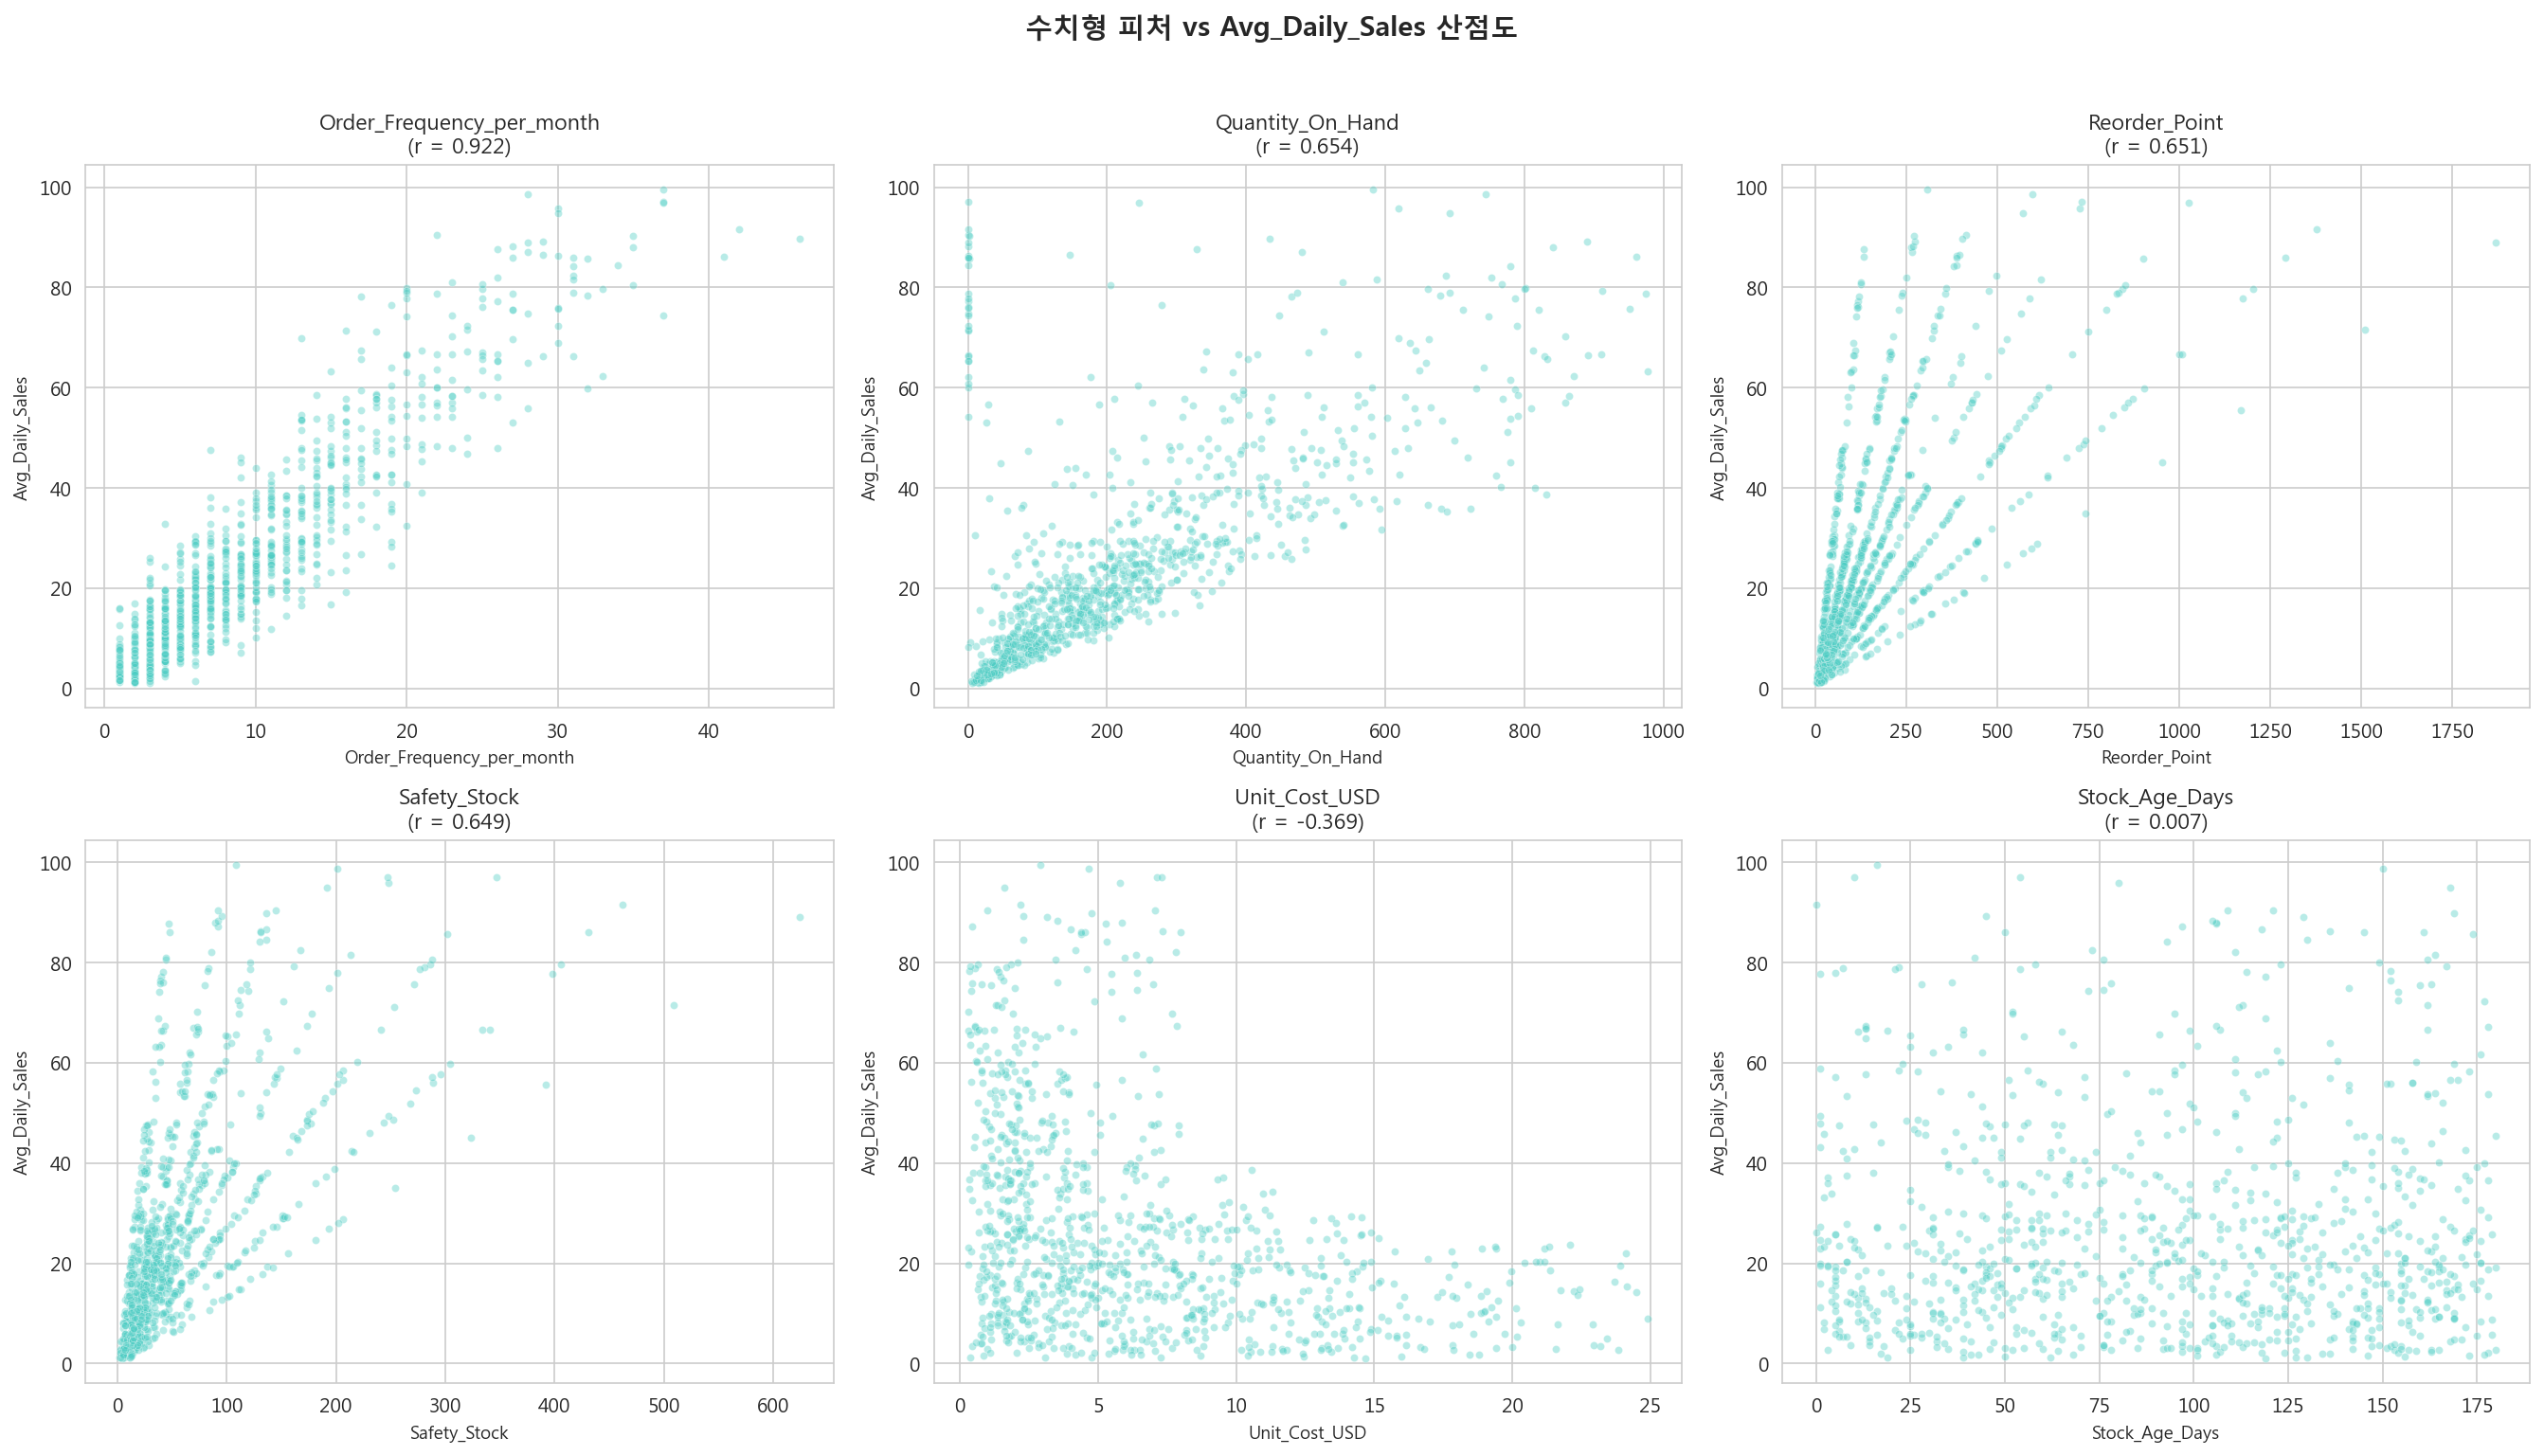

In [13]:
# ========================================
# 3.4 수치형 피처 vs Avg_Daily_Sales 산점도
# ========================================
scatter_features = ['Order_Frequency_per_month', 'Quantity_On_Hand', 'Reorder_Point',
                    'Safety_Stock', 'Unit_Cost_USD', 'Stock_Age_Days']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feat in enumerate(scatter_features):
    corr = df[feat].corr(df['Avg_Daily_Sales'])
    sns.scatterplot(data=df, x=feat, y='Avg_Daily_Sales', alpha=0.4, s=15,
                    color='#4ECDC4', ax=axes[i])
    axes[i].set_title(f'{feat}\n(r = {corr:.3f})', fontsize=11)
    axes[i].set_xlabel(feat, fontsize=9)
    axes[i].set_ylabel('Avg_Daily_Sales', fontsize=9)

plt.suptitle('수치형 피처 vs Avg_Daily_Sales 산점도', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'eda_scatter_features_s2.png'), dpi=150, bbox_inches='tight')
plt.show()

### 3.5 입고월(Received_Month)별 판매량 추이

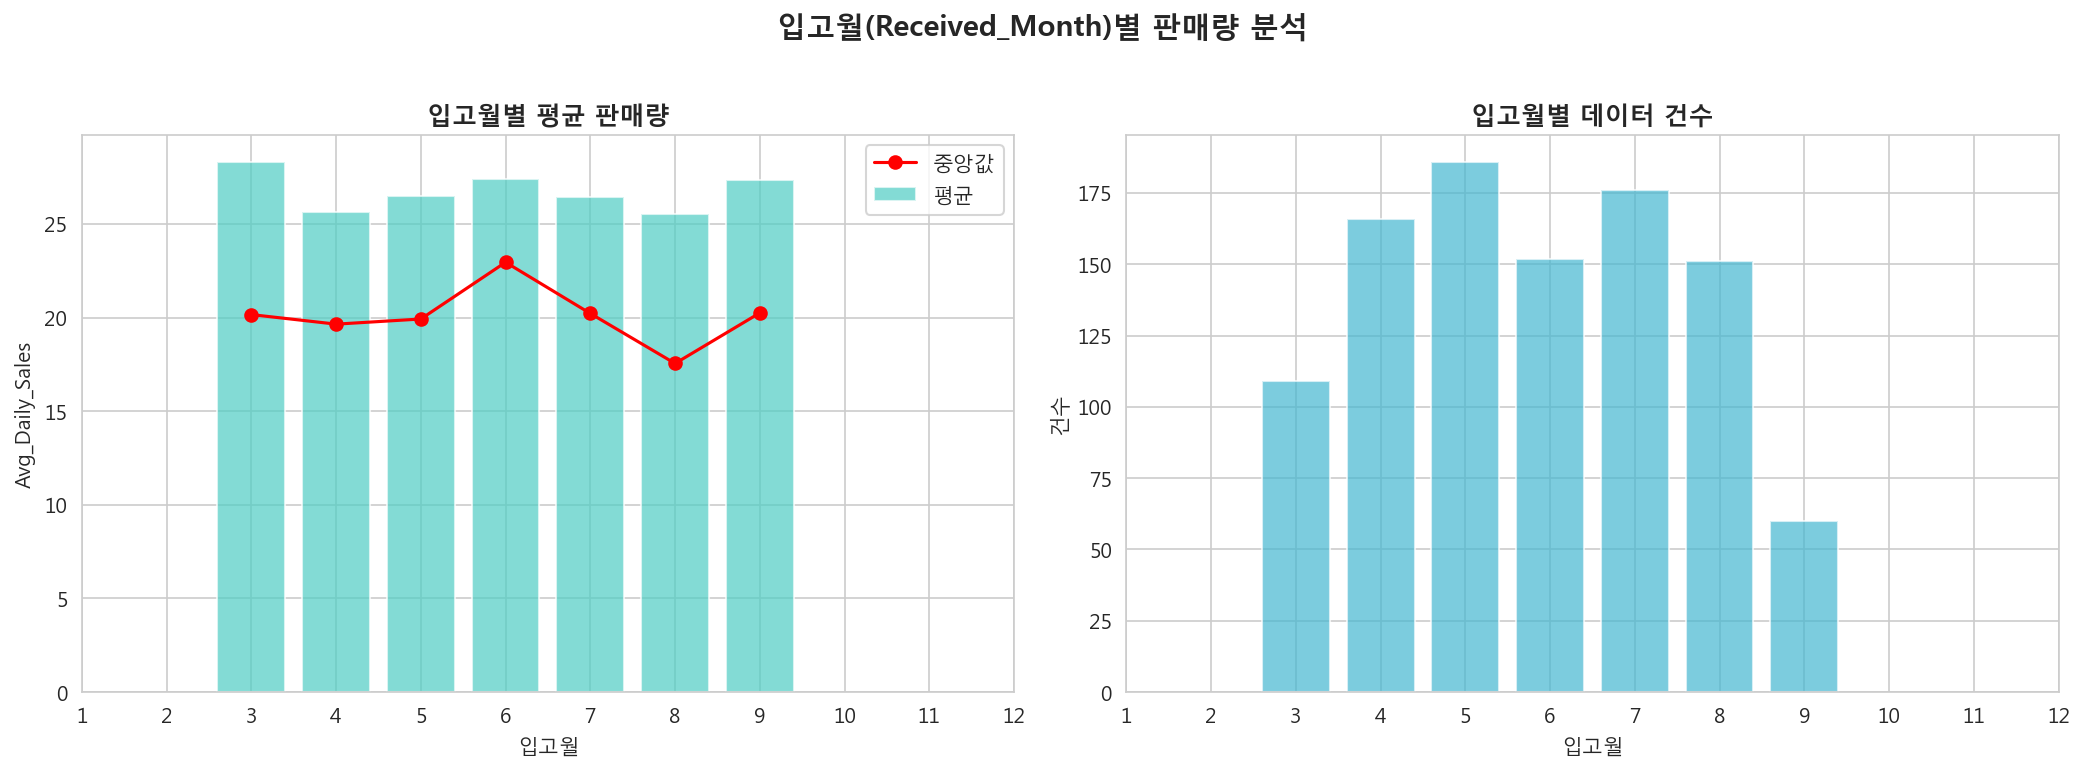

Received_Month vs Avg_Daily_Sales 상관계수: -0.0122
→ 뚜렷한 계절성 패턴 없음 (상관계수 ≈ 0)


In [14]:
# ========================================
# 3.5 Received_Month별 판매량 추이
# ========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 월별 평균 판매량
monthly = df.groupby('Received_Month')['Avg_Daily_Sales'].agg(['mean', 'median', 'count'])
axes[0].bar(monthly.index, monthly['mean'], color='#4ECDC4', alpha=0.7, label='평균')
axes[0].plot(monthly.index, monthly['median'], 'ro-', markersize=6, label='중앙값')
axes[0].set_title('입고월별 평균 판매량', fontweight='bold')
axes[0].set_xlabel('입고월')
axes[0].set_ylabel('Avg_Daily_Sales')
axes[0].set_xticks(range(1, 13))
axes[0].legend()

# 월별 건수
axes[1].bar(monthly.index, monthly['count'], color='#45B7D1', alpha=0.7)
axes[1].set_title('입고월별 데이터 건수', fontweight='bold')
axes[1].set_xlabel('입고월')
axes[1].set_ylabel('건수')
axes[1].set_xticks(range(1, 13))

plt.suptitle('입고월(Received_Month)별 판매량 분석', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'eda_monthly_sales_s2.png'), dpi=150, bbox_inches='tight')
plt.show()

# 상관관계
print(f'Received_Month vs Avg_Daily_Sales 상관계수: {df["Received_Month"].corr(df["Avg_Daily_Sales"]):.4f}')
print('→ 뚜렷한 계절성 패턴 없음 (상관계수 ≈ 0)')

### 3.6 피처 간 상관관계 히트맵

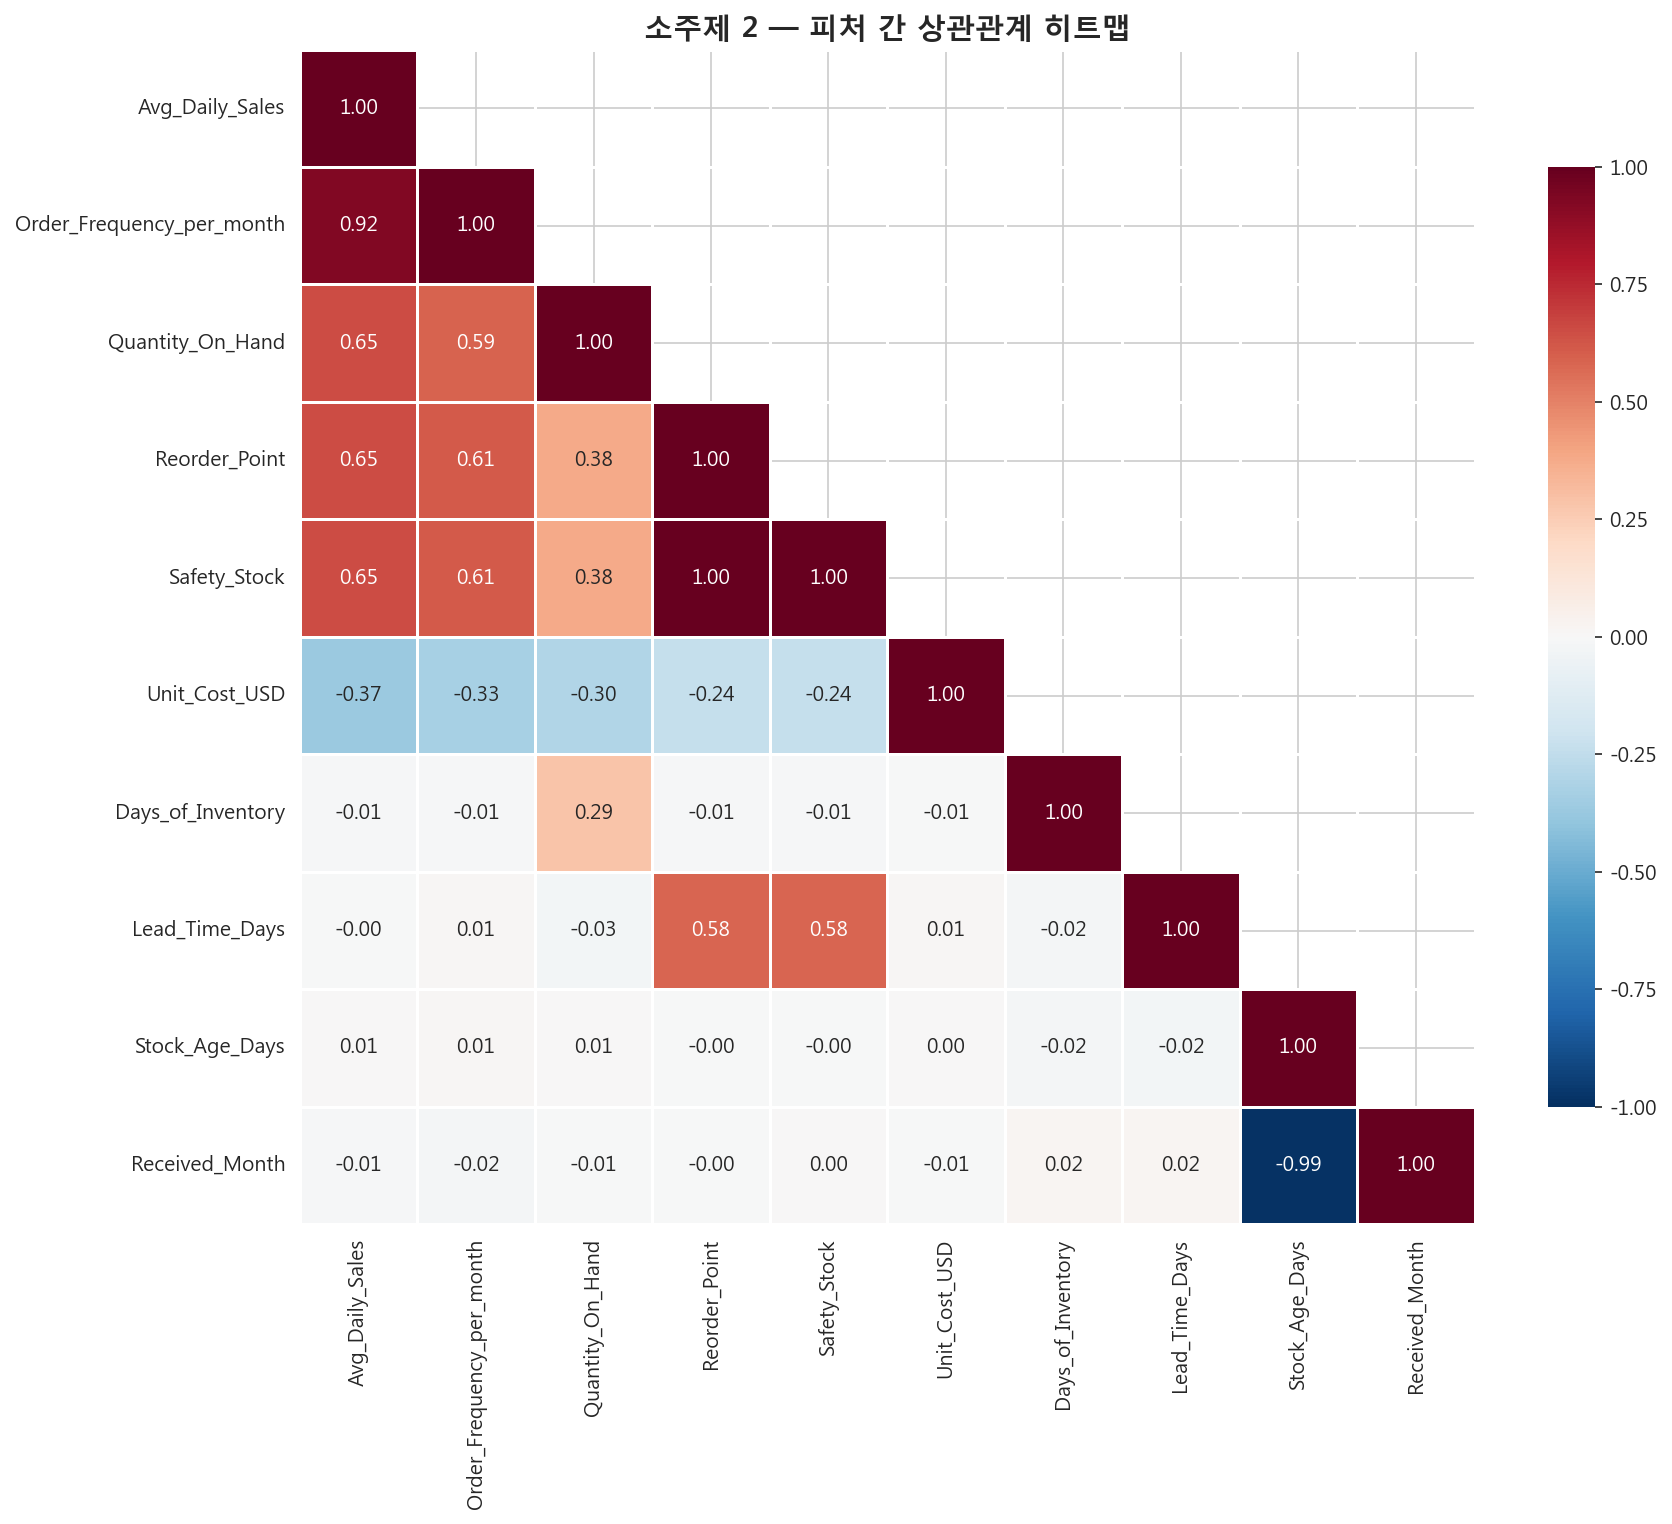

=== Avg_Daily_Sales와의 상관관계 (절대값 순) ===
   + Order_Frequency_per_month: 0.9225
   + Quantity_On_Hand: 0.6537
   + Reorder_Point: 0.6507
   + Safety_Stock: 0.6495
   - Unit_Cost_USD: -0.3688
   - Days_of_Inventory: -0.0130
   - Received_Month: -0.0122
   + Stock_Age_Days: 0.0065
   - Lead_Time_Days: -0.0028


In [15]:
# ========================================
# 3.6 피처 간 상관관계 히트맵
# ========================================
corr_features = ['Avg_Daily_Sales', 'Order_Frequency_per_month', 'Quantity_On_Hand',
                 'Reorder_Point', 'Safety_Stock', 'Unit_Cost_USD',
                 'Days_of_Inventory', 'Lead_Time_Days', 'Stock_Age_Days', 'Received_Month']

corr_matrix = df[corr_features].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax,
            vmin=-1, vmax=1, cbar_kws={'shrink': 0.8})
ax.set_title('소주제 2 — 피처 간 상관관계 히트맵', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'eda_correlation_heatmap_s2.png'), dpi=150, bbox_inches='tight')
plt.show()

print('=== Avg_Daily_Sales와의 상관관계 (절대값 순) ===')
ads_corr = corr_matrix['Avg_Daily_Sales'].drop('Avg_Daily_Sales').abs().sort_values(ascending=False)
for feat, val in ads_corr.items():
    sign = '+' if corr_matrix.loc['Avg_Daily_Sales', feat] > 0 else '-'
    print(f'   {sign} {feat}: {corr_matrix.loc["Avg_Daily_Sales", feat]:.4f}')

---
## 4. 데이터 누수(Data Leakage) 진단

> **소주제 1에서 발견된 데이터 누수 패턴과 동일한 구조적 문제가 소주제 2에도 존재한다.**
>
> `Days_of_Inventory`는 `Quantity_On_Hand / Avg_Daily_Sales`로 정의되는 직접 파생변수이므로,
> 이 피처와 `Quantity_On_Hand`를 함께 사용하면 타겟(Avg_Daily_Sales)을 역산할 수 있다.

In [16]:
# ========================================
# 4.1 Days_of_Inventory = QOH / ADS 수식 검증
# ========================================
computed_doi = df['Quantity_On_Hand'] / df['Avg_Daily_Sales']
diff = (computed_doi - df['Days_of_Inventory']).abs()

print('=== Days_of_Inventory = Quantity_On_Hand / Avg_Daily_Sales 검증 ===')
print(f'   완벽 일치 (차이 < 0.01): {(diff < 0.01).sum()} / {len(df)} ({(diff < 0.01).mean()*100:.1f}%)')
print(f'   최대 차이: {diff.max():.4f}')
print()

# 샘플 비교
sample_idx = [0, 1, 2, 3, 4]
print('--- 샘플 검증 ---')
print(f'{"SKU_ID":>10} {"QOH":>6} {"ADS":>8} {"DOI(실제)":>10} {"QOH/ADS":>10} {"차이":>8}')
for idx in sample_idx:
    row = df.iloc[idx]
    comp = row['Quantity_On_Hand'] / row['Avg_Daily_Sales']
    d = abs(comp - row['Days_of_Inventory'])
    print(f'{row["SKU_ID"]:>10} {row["Quantity_On_Hand"]:>6} {row["Avg_Daily_Sales"]:>8.2f} '
          f'{row["Days_of_Inventory"]:>10.2f} {comp:>10.2f} {d:>8.4f}')

print()
print('⚠️ 결론: Days_of_Inventory = QOH / ADS (타겟의 직접 파생변수)')
print('   → ADS = QOH / DOI 로 역산 가능 → 데이터 누수(Data Leakage)!')

=== Days_of_Inventory = Quantity_On_Hand / Avg_Daily_Sales 검증 ===
   완벽 일치 (차이 < 0.01): 972 / 1000 (97.2%)
   최대 차이: 21.9316

--- 샘플 검증 ---
    SKU_ID    QOH      ADS    DOI(실제)    QOH/ADS       차이
   SKU0001    359    28.57      12.57      12.57   0.0044
   SKU0002    314    34.99       8.97       8.97   0.0040
   SKU0003    485    36.55      13.27      13.27   0.0005
   SKU0004    281    25.49      11.02      11.02   0.0039
   SKU0005    235    17.05      13.78      13.78   0.0030

⚠️ 결론: Days_of_Inventory = QOH / ADS (타겟의 직접 파생변수)
   → ADS = QOH / DOI 로 역산 가능 → 데이터 누수(Data Leakage)!


In [17]:
# ========================================
# 4.2 누수 피처의 예측력 테스트
# ========================================
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor as RF_test

y_all = df['Avg_Daily_Sales'].values

# 단일 피처 R² (Linear Regression)
single_features = {
    'Days_of_Inventory': df[['Days_of_Inventory']].values,
    'Quantity_On_Hand': df[['Quantity_On_Hand']].values,
    'Order_Frequency_per_month': df[['Order_Frequency_per_month']].values,
}
print('=== 단일 피처 → Avg_Daily_Sales 예측 (Linear Regression, 전체 데이터) ===')
for name, X_feat in single_features.items():
    lr = LinearRegression().fit(X_feat, y_all)
    r2 = lr.score(X_feat, y_all)
    print(f'   {name}: R² = {r2:.4f}')

# DOI + QOH 조합 (Linear vs Random Forest)
X_leak = df[['Days_of_Inventory', 'Quantity_On_Hand']].values
lr_leak = LinearRegression().fit(X_leak, y_all)
rf_leak = RF_test(n_estimators=50, random_state=SEED).fit(X_leak, y_all)

print(f'\n=== DOI + QOH 조합 → ADS 예측 ===')
print(f'   Linear Regression: R² = {lr_leak.score(X_leak, y_all):.4f}')
print(f'   Random Forest:     R² = {rf_leak.score(X_leak, y_all):.4f}')
print(f'   → 비선형 모델(RF)은 ADS = QOH/DOI 관계를 거의 완벽히 학습!')

=== 단일 피처 → Avg_Daily_Sales 예측 (Linear Regression, 전체 데이터) ===
   Days_of_Inventory: R² = 0.0002
   Quantity_On_Hand: R² = 0.4274
   Order_Frequency_per_month: R² = 0.8509

=== DOI + QOH 조합 → ADS 예측 ===
   Linear Regression: R² = 0.4710
   Random Forest:     R² = 0.9911
   → 비선형 모델(RF)은 ADS = QOH/DOI 관계를 거의 완벽히 학습!


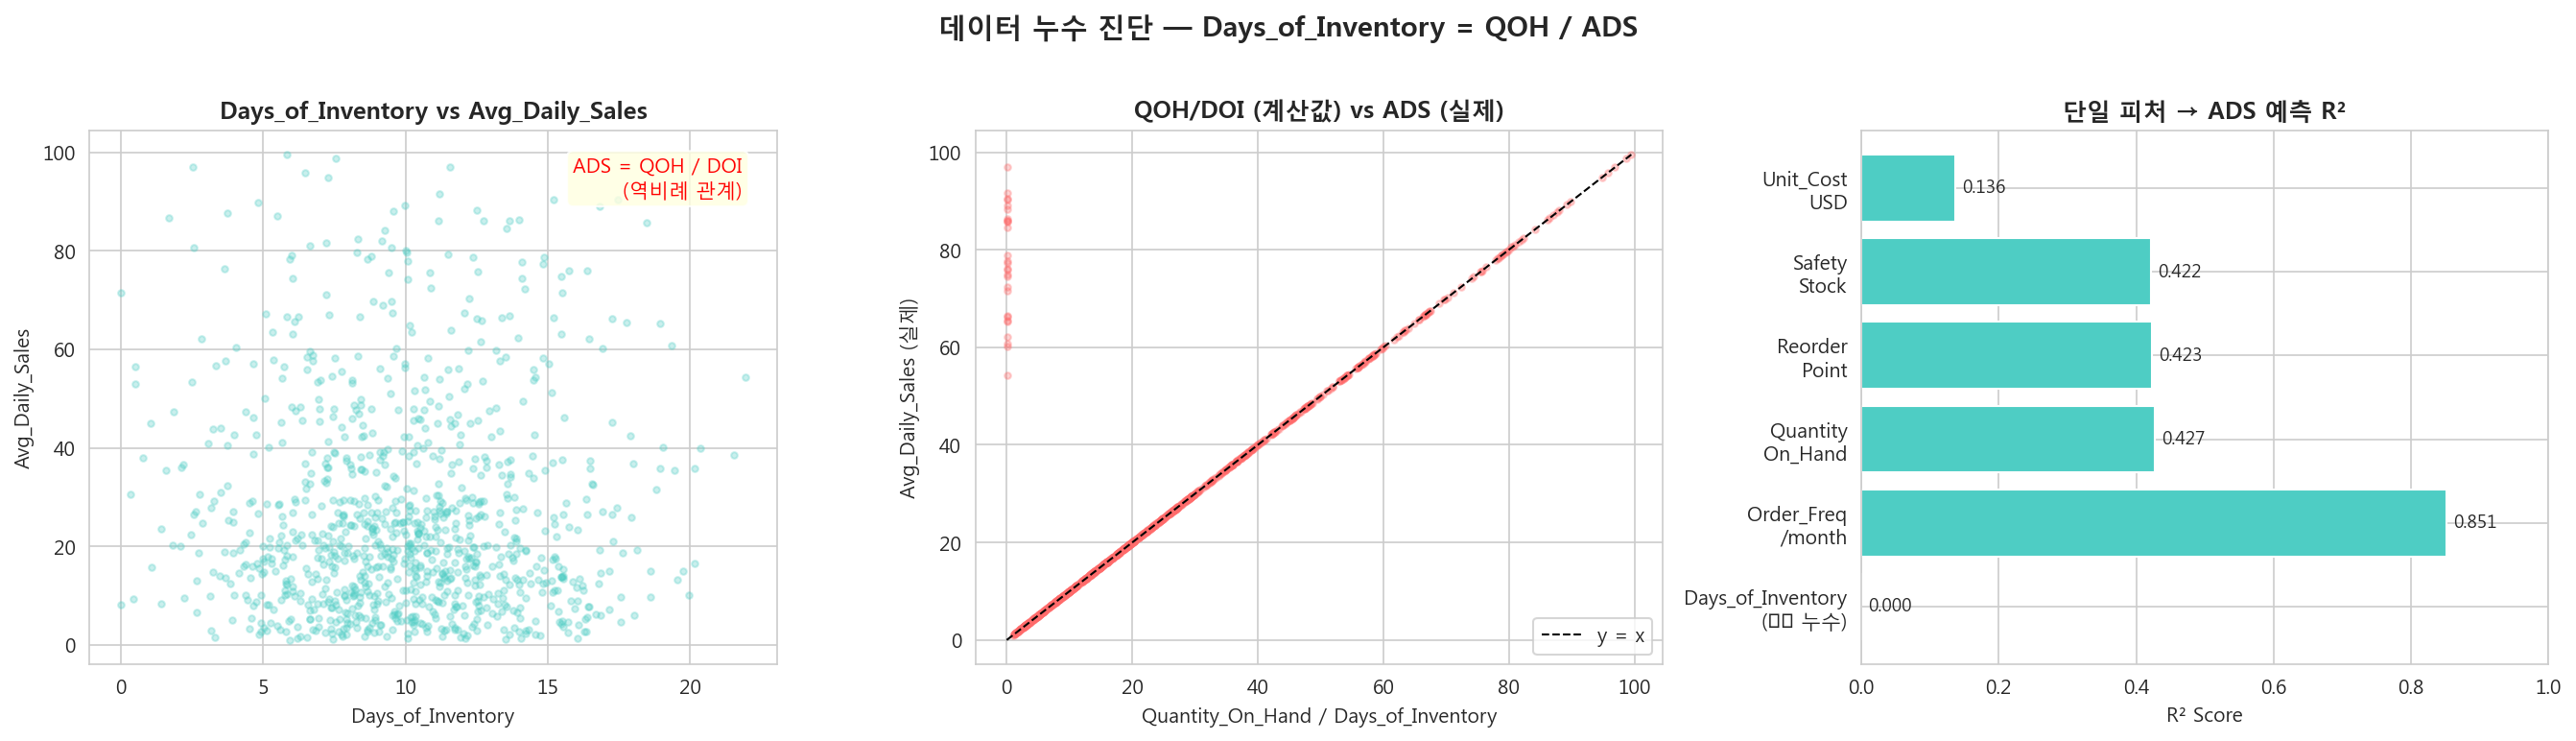


⚠️ 결론: Days_of_Inventory는 타겟의 직접 파생변수 → 피처에서 제거
   Scenario A (Full): DOI 포함 20개 피처 → 참고용
   Scenario B (Clean): DOI 제거 19개 피처 → 메인 분석


In [18]:
# ========================================
# 4.3 데이터 누수 시각화
# ========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (1) DOI vs ADS — 역비례 관계
axes[0].scatter(df['Days_of_Inventory'], df['Avg_Daily_Sales'], alpha=0.3, s=10, c='#4ECDC4')
axes[0].set_title('Days_of_Inventory vs Avg_Daily_Sales', fontweight='bold')
axes[0].set_xlabel('Days_of_Inventory')
axes[0].set_ylabel('Avg_Daily_Sales')
axes[0].annotate('ADS = QOH / DOI\n(역비례 관계)', xy=(0.95, 0.95), xycoords='axes fraction',
                ha='right', va='top', fontsize=10, color='red',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

# (2) QOH/DOI vs ADS — 완벽한 선형 관계
computed_ads = df['Quantity_On_Hand'] / df['Days_of_Inventory']
computed_ads = computed_ads.replace([np.inf, -np.inf], np.nan).dropna()
actual_ads = df.loc[computed_ads.index, 'Avg_Daily_Sales']
axes[1].scatter(computed_ads, actual_ads, alpha=0.3, s=10, c='#FF6B6B')
max_val = max(computed_ads.max(), actual_ads.max())
axes[1].plot([0, max_val], [0, max_val], 'k--', linewidth=1, label='y = x')
axes[1].set_title('QOH/DOI (계산값) vs ADS (실제)', fontweight='bold')
axes[1].set_xlabel('Quantity_On_Hand / Days_of_Inventory')
axes[1].set_ylabel('Avg_Daily_Sales (실제)')
axes[1].legend()

# (3) 단일 피처 R² 비교
feat_names = ['Days_of_Inventory\n(⚠️ 누수)', 'Order_Freq\n/month', 'Quantity\nOn_Hand',
              'Reorder\nPoint', 'Safety\nStock', 'Unit_Cost\nUSD']
feat_cols = ['Days_of_Inventory', 'Order_Frequency_per_month', 'Quantity_On_Hand',
             'Reorder_Point', 'Safety_Stock', 'Unit_Cost_USD']
r2_vals = []
for col in feat_cols:
    lr_tmp = LinearRegression().fit(df[[col]].values, y_all)
    r2_vals.append(lr_tmp.score(df[[col]].values, y_all))
colors = ['#FF6B6B'] + ['#4ECDC4'] * 5  # 누수 피처는 빨간색
axes[2].barh(feat_names, r2_vals, color=colors)
axes[2].set_title('단일 피처 → ADS 예측 R²', fontweight='bold')
axes[2].set_xlabel('R² Score')
axes[2].set_xlim(0, 1)
for i, v in enumerate(r2_vals):
    axes[2].text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)

plt.suptitle('데이터 누수 진단 — Days_of_Inventory = QOH / ADS', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'data_leakage_diagnosis_s2.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\n⚠️ 결론: Days_of_Inventory는 타겟의 직접 파생변수 → 피처에서 제거')
print('   Scenario A (Full): DOI 포함 20개 피처 → 참고용')
print('   Scenario B (Clean): DOI 제거 19개 피처 → 메인 분석')

### 4.4 Order_Frequency_per_month 준누수(Quasi-Leakage) 검증 ★

> `Order_Frequency_per_month`는 타겟(Avg_Daily_Sales)과 상관계수 **0.92**로 압도적 1위.  
> "많이 팔리는 제품을 더 자주 발주" → 발주 빈도는 판매량의 **결과**일 가능성 검토.  
> 수학적 파생 관계(DOI = QOH/ADS)가 아니므로 엄밀한 누수는 아니지만, 과도한 의존도를 정량화한다.

Order_Frequency_per_month 준누수 검증 결과

시나리오                           LR R²      RF R²
--------------------------------------------------
B-1 (포함)                      0.8832     0.9122
B-2 (제거)                      0.7481     0.9175
ΔR² (B1 - B2)                 0.1351    -0.0052

✅ Order_Frequency 제거 시 R² 하락폭 < 0.1 → 과도한 의존 없음

📌 결론: Order_Frequency_per_month는 수학적 파생변수가 아니므로
   데이터 누수가 아닌 강한 예측 변수로 판단.
   단, 인과 방향(판매→발주 vs 발주→판매)에 대한 해석은 결과 보고서에서 논의.


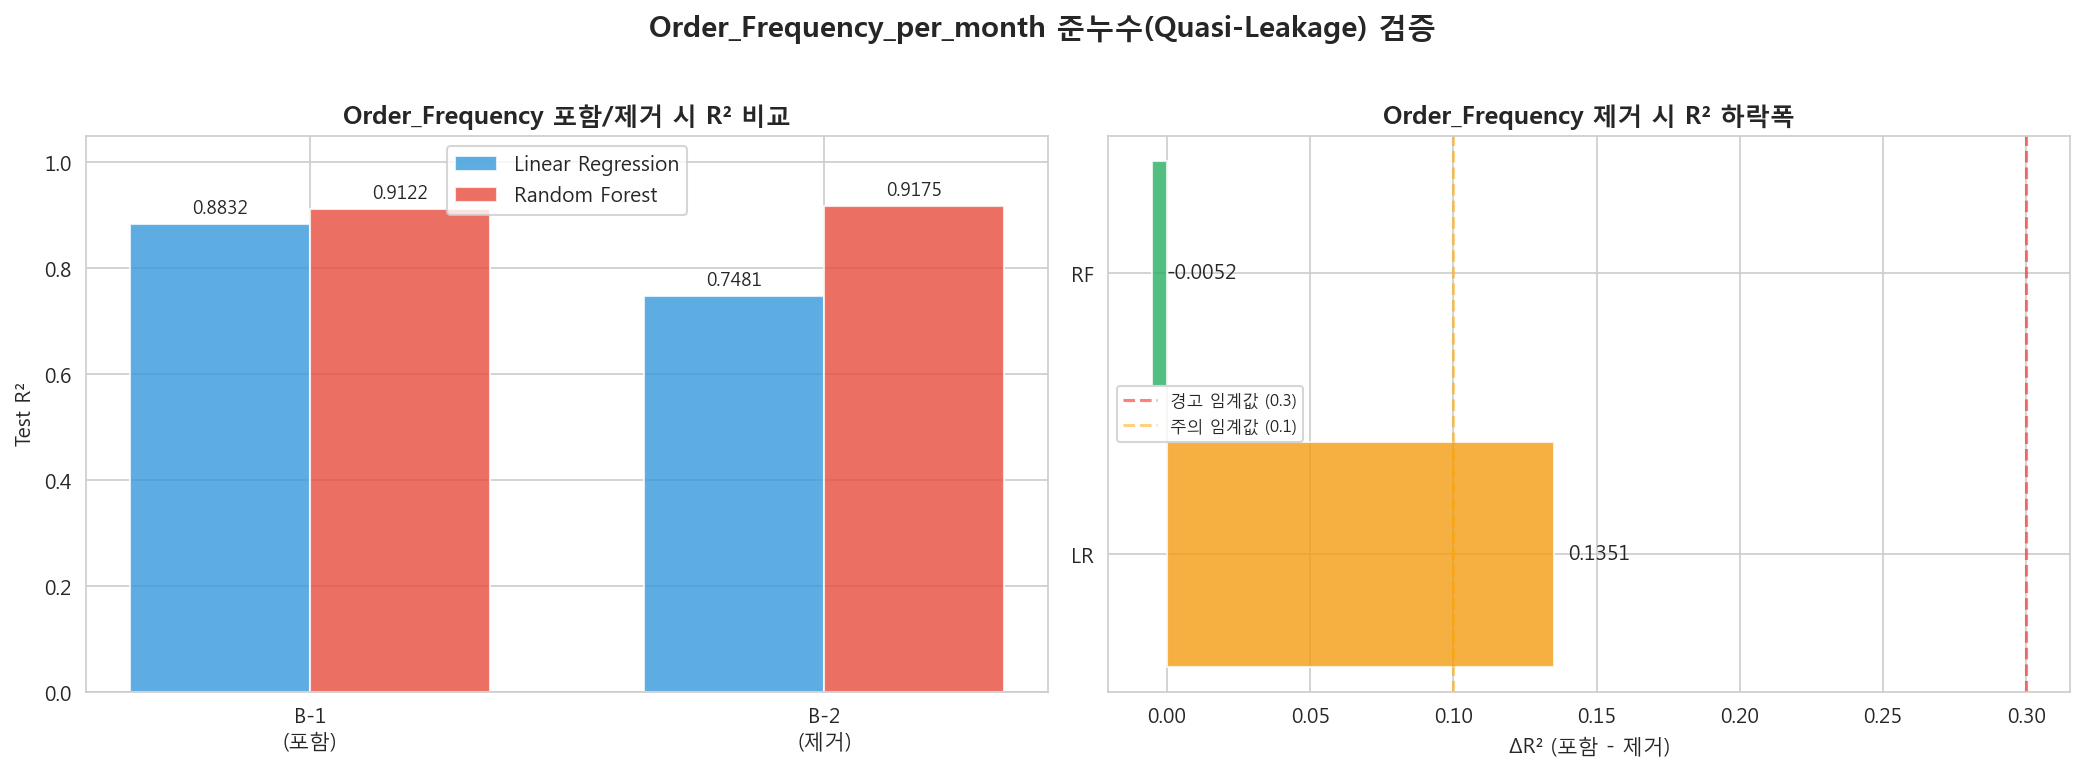

In [19]:
# ========================================
# 4.4 Order_Frequency_per_month 준누수 검증
# ========================================

# 피처 목록 정의 (Scenario B 기준)
numeric_features = ['Unit_Cost_USD', 'Quantity_On_Hand', 'Reorder_Point', 'Safety_Stock',
                    'Lead_Time_Days', 'Stock_Age_Days', 'Order_Frequency_per_month', 'Received_Month']
cat_features = ['Category', 'ABC_Class']

# 임시 인코딩
df_temp = pd.get_dummies(df[numeric_features + cat_features], columns=cat_features, drop_first=True)
y_temp = df['Avg_Daily_Sales']

X_tr, X_te, y_tr, y_te = train_test_split(df_temp, y_temp, test_size=0.2, random_state=42)

sc_temp = StandardScaler()
X_tr_s = sc_temp.fit_transform(X_tr)
X_te_s = sc_temp.transform(X_te)

# Scenario B-1: Order_Frequency 포함 (기존)
rf_b1 = RandomForestRegressor(n_estimators=100, random_state=42)
rf_b1.fit(X_tr_s, y_tr)
r2_b1 = r2_score(y_te, rf_b1.predict(X_te_s))

lr_b1 = LinearRegression()
lr_b1.fit(X_tr_s, y_tr)
r2_lr_b1 = r2_score(y_te, lr_b1.predict(X_te_s))

# Scenario B-2: Order_Frequency 제거
drop_col = 'Order_Frequency_per_month'
feat_b2 = [c for c in df_temp.columns if c != drop_col]
X_tr_b2 = sc_temp.fit_transform(X_tr[feat_b2])
X_te_b2 = sc_temp.transform(X_te[feat_b2])

rf_b2 = RandomForestRegressor(n_estimators=100, random_state=42)
rf_b2.fit(X_tr_b2, y_tr)
r2_b2 = r2_score(y_te, rf_b2.predict(X_te_b2))

lr_b2 = LinearRegression()
lr_b2.fit(X_tr_b2, y_tr)
r2_lr_b2 = r2_score(y_te, lr_b2.predict(X_te_b2))

delta_rf = r2_b1 - r2_b2
delta_lr = r2_lr_b1 - r2_lr_b2

print('=' * 60)
print('Order_Frequency_per_month 준누수 검증 결과')
print('=' * 60)
print(f'\n{"시나리오":<25} {"LR R²":>10} {"RF R²":>10}')
print('-' * 50)
print(f'{"B-1 (포함)":<25} {r2_lr_b1:>10.4f} {r2_b1:>10.4f}')
print(f'{"B-2 (제거)":<25} {r2_lr_b2:>10.4f} {r2_b2:>10.4f}')
print(f'{"ΔR² (B1 - B2)":<25} {delta_lr:>10.4f} {delta_rf:>10.4f}')
print()

if delta_rf > 0.3:
    print('⚠️ Order_Frequency 제거 시 R² 하락폭이 0.3 초과 → 과도한 의존')
    print('   → Scenario B에 포함하되, 해석 시 주의 필요')
elif delta_rf > 0.1:
    print('⚠️ Order_Frequency 제거 시 R² 하락폭 0.1~0.3 → 상당한 의존')
    print('   → 이 변수 없이는 예측 성능이 유의미하게 감소')
else:
    print('✅ Order_Frequency 제거 시 R² 하락폭 < 0.1 → 과도한 의존 없음')

print()
print('📌 결론: Order_Frequency_per_month는 수학적 파생변수가 아니므로')
print('   데이터 누수가 아닌 강한 예측 변수로 판단.')
print('   단, 인과 방향(판매→발주 vs 발주→판매)에 대한 해석은 결과 보고서에서 논의.')

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (1) R² 비교 바 차트
scenarios = ['B-1\n(포함)', 'B-2\n(제거)']
lr_vals = [r2_lr_b1, r2_lr_b2]
rf_vals = [r2_b1, r2_b2]
x = np.arange(len(scenarios))
w = 0.35

axes[0].bar(x - w/2, lr_vals, w, label='Linear Regression', color='#3498db', alpha=0.8)
axes[0].bar(x + w/2, rf_vals, w, label='Random Forest', color='#e74c3c', alpha=0.8)
axes[0].set_ylabel('Test R²')
axes[0].set_title('Order_Frequency 포함/제거 시 R² 비교', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(scenarios)
axes[0].legend()
axes[0].set_ylim(0, 1.05)

for i, (lv, rv) in enumerate(zip(lr_vals, rf_vals)):
    axes[0].text(i - w/2, lv + 0.02, f'{lv:.4f}', ha='center', fontsize=9)
    axes[0].text(i + w/2, rv + 0.02, f'{rv:.4f}', ha='center', fontsize=9)

# (2) ΔR² 바 차트
models = ['LR', 'RF']
deltas = [delta_lr, delta_rf]
colors = ['#e74c3c' if d > 0.3 else '#f39c12' if d > 0.1 else '#27ae60' for d in deltas]
axes[1].barh(models, deltas, color=colors, alpha=0.8)
axes[1].set_xlabel('ΔR² (포함 - 제거)')
axes[1].set_title('Order_Frequency 제거 시 R² 하락폭', fontweight='bold')
axes[1].axvline(0.3, color='red', linestyle='--', alpha=0.5, label='경고 임계값 (0.3)')
axes[1].axvline(0.1, color='orange', linestyle='--', alpha=0.5, label='주의 임계값 (0.1)')
axes[1].legend(fontsize=8)

for i, d in enumerate(deltas):
    axes[1].text(d + 0.005, i, f'{d:.4f}', va='center', fontsize=10)

plt.suptitle('Order_Frequency_per_month 준누수(Quasi-Leakage) 검증', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'order_freq_quasi_leakage_s2.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 5. 피처/타겟 분리 & Train/Test Split

> **Scenario B (Clean)**를 메인으로 사용: `Days_of_Inventory` 제거

In [20]:
# ========================================
# 5.1 피처 선택 & One-Hot 인코딩
# ========================================
# 수치형 피처 (누수 제거)
num_features = ['Unit_Cost_USD', 'Quantity_On_Hand', 'Reorder_Point', 'Safety_Stock',
                'Lead_Time_Days', 'Stock_Age_Days', 'Order_Frequency_per_month', 'Received_Month']

# 범주형 피처 → One-Hot
cat_dummies = pd.get_dummies(df[['Category', 'ABC_Class']], drop_first=True)

# 피처 결합
X = pd.concat([df[num_features], cat_dummies], axis=1)
y = df['Avg_Daily_Sales']

print(f'=== Scenario B (Clean) — 누수 피처 제거 ===')
print(f'   수치형 피처: {len(num_features)}개')
print(f'   범주형 피처 (One-Hot): {cat_dummies.shape[1]}개')
print(f'   총 피처 수: {X.shape[1]}개')
print(f'   타겟 변수: Avg_Daily_Sales ({len(y)}건)')
print(f'\n   피처 목록:')
for i, col in enumerate(X.columns, 1):
    print(f'   {i:2d}. {col}')

=== Scenario B (Clean) — 누수 피처 제거 ===
   수치형 피처: 8개
   범주형 피처 (One-Hot): 11개
   총 피처 수: 19개
   타겟 변수: Avg_Daily_Sales (1000건)

   피처 목록:
    1. Unit_Cost_USD
    2. Quantity_On_Hand
    3. Reorder_Point
    4. Safety_Stock
    5. Lead_Time_Days
    6. Stock_Age_Days
    7. Order_Frequency_per_month
    8. Received_Month
    9. Category_Beverages
   10. Category_Dairy
   11. Category_Fresh Produce
   12. Category_Frozen
   13. Category_Household
   14. Category_Meat
   15. Category_Pantry
   16. Category_Personal Care
   17. Category_Seafood
   18. ABC_Class_B
   19. ABC_Class_C


In [21]:
# ========================================
# 5.2 Train/Test Split & Scaling
# ========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# DataFrame으로 변환 (SHAP에서 피처명 필요)
feature_names = X.columns.tolist()
X_train_df = pd.DataFrame(X_train_scaled, columns=feature_names, index=X_train.index)
X_test_df = pd.DataFrame(X_test_scaled, columns=feature_names, index=X_test.index)

print(f'✅ Train/Test Split 완료')
print(f'   Train: {X_train.shape[0]}건 ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'   Test:  {X_test.shape[0]}건 ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'\n✅ StandardScaler 적용 완료')
print(f'   Train y — 평균: {y_train.mean():.2f}, 표준편차: {y_train.std():.2f}')
print(f'   Test  y — 평균: {y_test.mean():.2f}, 표준편차: {y_test.std():.2f}')

✅ Train/Test Split 완료
   Train: 800건 (80%)
   Test:  200건 (20%)

✅ StandardScaler 적용 완료
   Train y — 평균: 27.11, 표준편차: 21.30
   Test  y — 평균: 24.47, 표준편차: 20.98


---
## 6. 모델 학습 & 평가

### 6.1 Default 모델 학습 (5종)

In [22]:
# ========================================
# 6.1 Default 모델 학습
# ========================================
default_models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0, random_state=SEED),
    'Lasso': Lasso(alpha=1.0, max_iter=10000, random_state=SEED),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=SEED),
    'XGBoost': XGBRegressor(n_estimators=100, objective='reg:squarederror',
                            random_state=SEED, verbosity=0)
}

default_results = []
default_trained = {}

for name, model in default_models.items():
    model.fit(X_train_scaled, y_train)
    default_trained[name] = model

    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    mae = mean_absolute_error(y_test, y_test_pred)
    gap = train_r2 - test_r2

    default_results.append({
        '모델': name,
        'Train R²': round(train_r2, 4),
        'Test R²': round(test_r2, 4),
        'RMSE': round(rmse, 2),
        'MAE': round(mae, 2),
        'Gap': round(gap, 4)
    })
    print(f'{name:>20s}: Train R²={train_r2:.4f}, Test R²={test_r2:.4f}, '
          f'RMSE={rmse:.2f}, MAE={mae:.2f}, Gap={gap:.4f}')

default_df = pd.DataFrame(default_results).sort_values('Test R²', ascending=False)
print('\n=== Default 모델 성능 비교 ===')
display(default_df)

   Linear Regression: Train R²=0.9078, Test R²=0.8832, RMSE=7.15, MAE=5.46, Gap=0.0245
               Ridge: Train R²=0.9077, Test R²=0.8835, RMSE=7.14, MAE=5.46, Gap=0.0242
               Lasso: Train R²=0.8892, Test R²=0.8708, RMSE=7.52, MAE=5.61, Gap=0.0184


       Random Forest: Train R²=0.9886, Test R²=0.9122, RMSE=6.20, MAE=4.33, Gap=0.0763
             XGBoost: Train R²=1.0000, Test R²=0.9416, RMSE=5.06, MAE=3.11, Gap=0.0584

=== Default 모델 성능 비교 ===


,모델,Train R²,Test R²,RMSE,MAE,Gap
4,XGBoost,1.0000,0.9416,5.06,3.11,0.0584
3,Random Forest,0.9886,0.9122,6.20,4.33,0.0763
1,Ridge,0.9077,0.8835,7.14,5.46,0.0242
0,Linear Regression,0.9078,0.8832,7.15,5.46,0.0245
2,Lasso,0.8892,0.8708,7.52,5.61,0.0184


### 6.2 교차검증 (5-Fold CV)

In [23]:
# ========================================
# 6.2 교차검증 (5-Fold CV)
# ========================================
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

cv_results = []
for name, model_class in [
    ('Linear Regression', LinearRegression()),
    ('Ridge', Ridge(alpha=1.0, random_state=SEED)),
    ('Lasso', Lasso(alpha=1.0, max_iter=10000, random_state=SEED)),
    ('Random Forest', RandomForestRegressor(n_estimators=100, random_state=SEED)),
    ('XGBoost', XGBRegressor(n_estimators=100, objective='reg:squarederror',
                             random_state=SEED, verbosity=0))
]:
    scores = cross_val_score(model_class, X_train_scaled, y_train, cv=kf, scoring='r2')
    cv_results.append({
        '모델': name,
        'CV R² (Mean)': round(scores.mean(), 4),
        'CV R² (Std)': round(scores.std(), 4),
        'CV R² (Min)': round(scores.min(), 4),
        'CV R² (Max)': round(scores.max(), 4)
    })
    print(f'{name:>20s}: CV R² = {scores.mean():.4f} ± {scores.std():.4f}  '
          f'(Min: {scores.min():.4f}, Max: {scores.max():.4f})')

cv_df = pd.DataFrame(cv_results).sort_values('CV R² (Mean)', ascending=False)
print('\n=== 교차검증 결과 ===')
display(cv_df)

   Linear Regression: CV R² = 0.8995 ± 0.0123  (Min: 0.8876, Max: 0.9217)
               Ridge: CV R² = 0.9001 ± 0.0119  (Min: 0.8876, Max: 0.9220)


               Lasso: CV R² = 0.8835 ± 0.0185  (Min: 0.8656, Max: 0.9183)


       Random Forest: CV R² = 0.9114 ± 0.0159  (Min: 0.8952, Max: 0.9337)


             XGBoost: CV R² = 0.9250 ± 0.0129  (Min: 0.9068, Max: 0.9402)

=== 교차검증 결과 ===


,모델,CV R² (Mean),CV R² (Std),CV R² (Min),CV R² (Max)
4,XGBoost,0.9250,0.0129,0.9068,0.9402
3,Random Forest,0.9114,0.0159,0.8952,0.9337
1,Ridge,0.9001,0.0119,0.8876,0.9220
0,Linear Regression,0.8995,0.0123,0.8876,0.9217
2,Lasso,0.8835,0.0185,0.8656,0.9183


### 6.3 하이퍼파라미터 튜닝 (과적합 방지)

In [24]:
# ========================================
# 6.3 하이퍼파라미터 튜닝
# ========================================
# Ridge: alpha 탐색
from sklearn.model_selection import GridSearchCV

ridge_params = {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}
ridge_gs = GridSearchCV(Ridge(random_state=SEED), ridge_params, cv=kf, scoring='r2', n_jobs=-1)
ridge_gs.fit(X_train_scaled, y_train)
print(f'Ridge 최적 alpha: {ridge_gs.best_params_["alpha"]} (CV R²: {ridge_gs.best_score_:.4f})')

# Lasso: alpha 탐색
lasso_params = {'alpha': [0.001, 0.01, 0.1, 0.5, 1.0]}
lasso_gs = GridSearchCV(Lasso(max_iter=10000, random_state=SEED), lasso_params, cv=kf, scoring='r2', n_jobs=-1)
lasso_gs.fit(X_train_scaled, y_train)
print(f'Lasso 최적 alpha: {lasso_gs.best_params_["alpha"]} (CV R²: {lasso_gs.best_score_:.4f})')

# Tuned 모델 정의
tuned_models = {
    'Linear Regression': LinearRegression(),
    'Ridge (Tuned)': Ridge(alpha=ridge_gs.best_params_['alpha'], random_state=SEED),
    'Lasso (Tuned)': Lasso(alpha=lasso_gs.best_params_['alpha'], max_iter=10000, random_state=SEED),
    'Random Forest (Tuned)': RandomForestRegressor(
        n_estimators=200, max_depth=10, min_samples_leaf=5,
        min_samples_split=10, random_state=SEED
    ),
    'XGBoost (Tuned)': XGBRegressor(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0,
        objective='reg:squarederror', random_state=SEED, verbosity=0
    )
}

tuned_results = []
tuned_trained = {}

for name, model in tuned_models.items():
    model.fit(X_train_scaled, y_train)
    tuned_trained[name] = model

    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    mae = mean_absolute_error(y_test, y_test_pred)
    gap = train_r2 - test_r2

    tuned_results.append({
        '모델': name,
        'Train R²': round(train_r2, 4),
        'Test R²': round(test_r2, 4),
        'RMSE': round(rmse, 2),
        'MAE': round(mae, 2),
        'Gap': round(gap, 4)
    })
    print(f'{name:>25s}: Train R²={train_r2:.4f}, Test R²={test_r2:.4f}, '
          f'RMSE={rmse:.2f}, MAE={mae:.2f}, Gap={gap:.4f}')

tuned_df = pd.DataFrame(tuned_results).sort_values('Test R²', ascending=False)
print('\n=== Tuned 모델 성능 비교 ===')
display(tuned_df)

Ridge 최적 alpha: 10.0 (CV R²: 0.9003)
Lasso 최적 alpha: 0.01 (CV R²: 0.9000)
        Linear Regression: Train R²=0.9078, Test R²=0.8832, RMSE=7.15, MAE=5.46, Gap=0.0245
            Ridge (Tuned): Train R²=0.9075, Test R²=0.8840, RMSE=7.13, MAE=5.45, Gap=0.0235
            Lasso (Tuned): Train R²=0.9077, Test R²=0.8841, RMSE=7.12, MAE=5.44, Gap=0.0236


    Random Forest (Tuned): Train R²=0.9588, Test R²=0.9045, RMSE=6.47, MAE=4.50, Gap=0.0543


          XGBoost (Tuned): Train R²=0.9913, Test R²=0.9477, RMSE=4.79, MAE=3.32, Gap=0.0436

=== Tuned 모델 성능 비교 ===


,모델,Train R²,Test R²,RMSE,MAE,Gap
4,XGBoost (Tuned),0.9913,0.9477,4.79,3.32,0.0436
3,Random Forest (Tuned),0.9588,0.9045,6.47,4.50,0.0543
2,Lasso (Tuned),0.9077,0.8841,7.12,5.44,0.0236
1,Ridge (Tuned),0.9075,0.8840,7.13,5.45,0.0235
0,Linear Regression,0.9078,0.8832,7.15,5.46,0.0245


### 6.4 Default vs Tuned 성능 비교

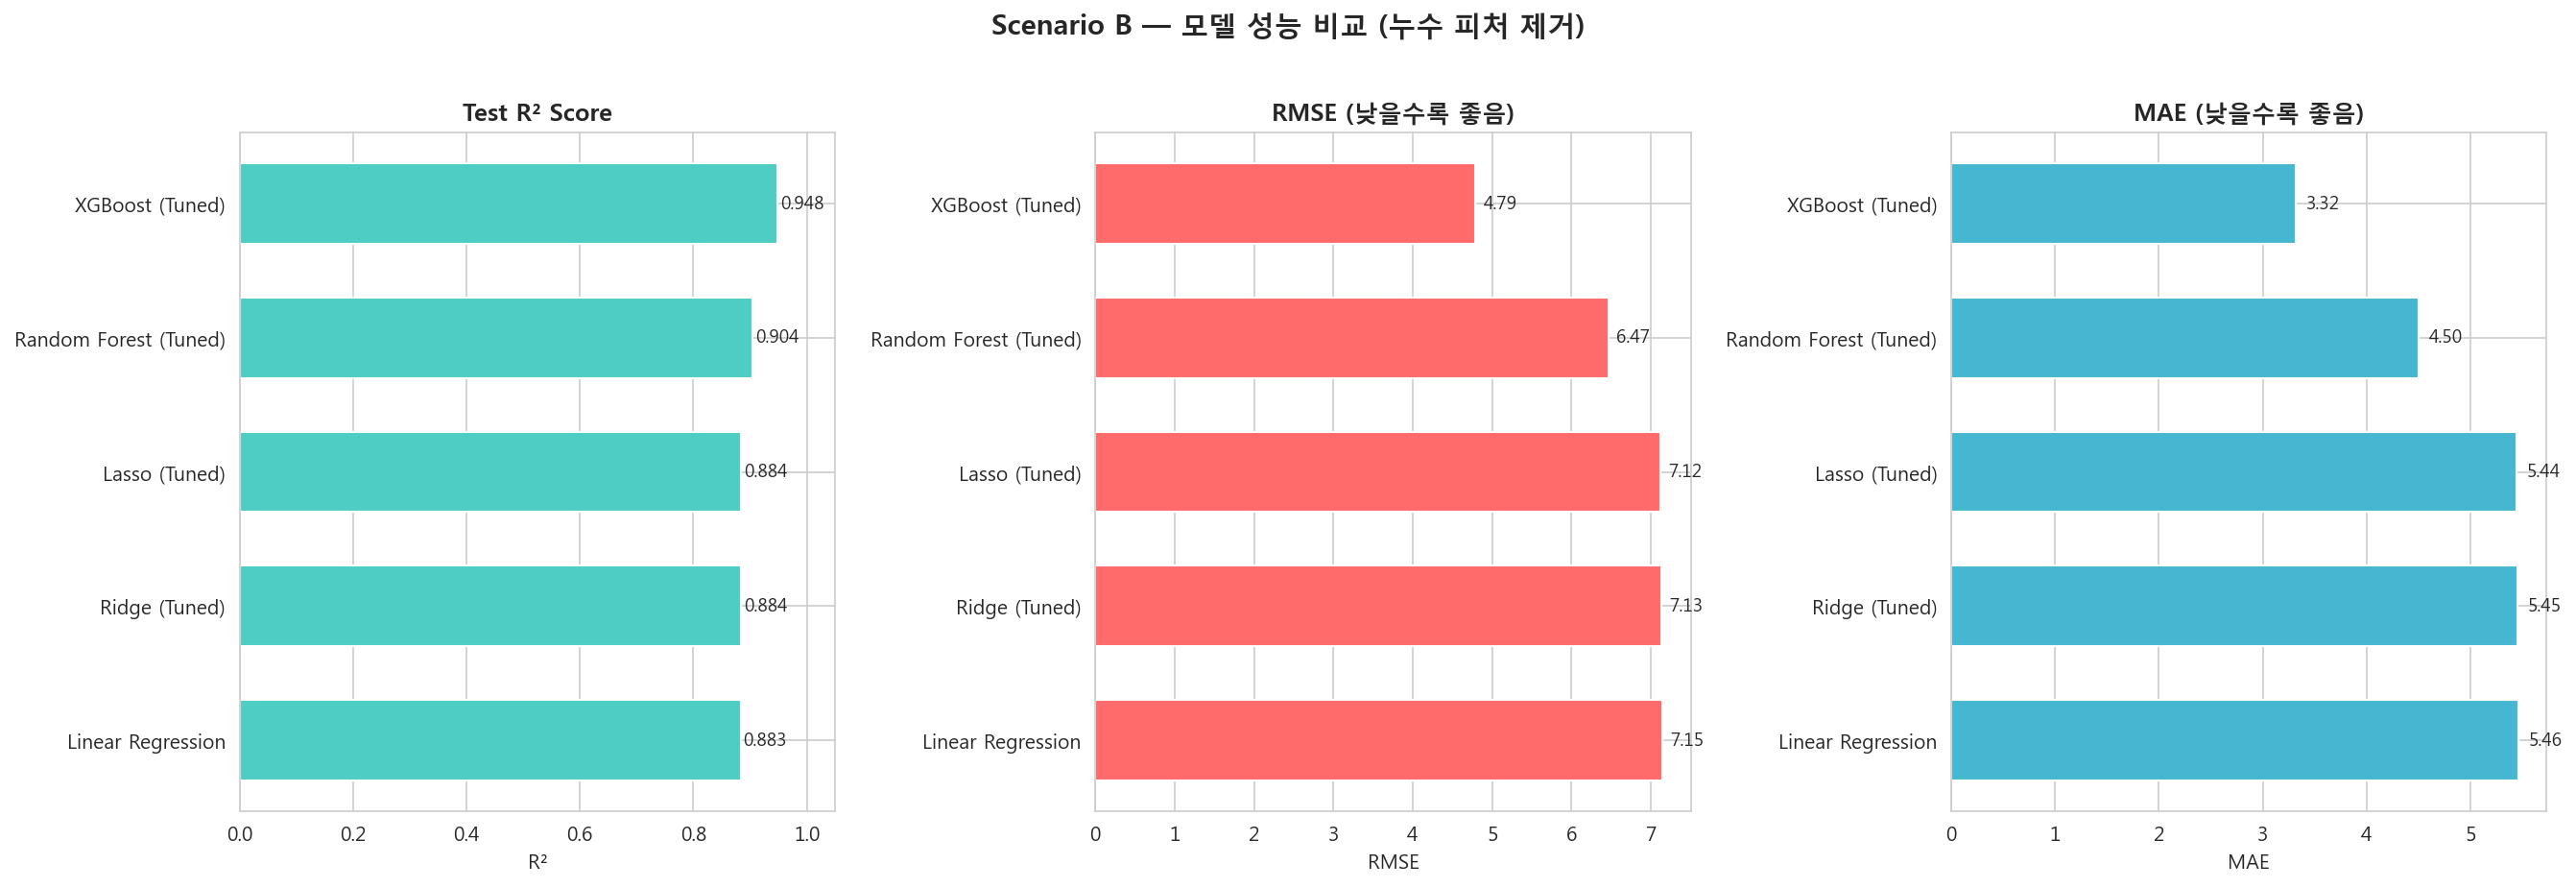

In [25]:
# ========================================
# 6.4 모델 성능 비교 시각화
# ========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

tuned_sorted = tuned_df.sort_values('Test R²', ascending=True)
models = tuned_sorted['모델'].values

# R² 비교
axes[0].barh(models, tuned_sorted['Test R²'].values, color='#4ECDC4', height=0.6)
for i, (v, tv) in enumerate(zip(tuned_sorted['Test R²'].values, tuned_sorted['Train R²'].values)):
    axes[0].text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)
axes[0].set_title('Test R² Score', fontweight='bold')
axes[0].set_xlabel('R²')
axes[0].set_xlim(0, 1.05)

# RMSE 비교
axes[1].barh(models, tuned_sorted['RMSE'].values, color='#FF6B6B', height=0.6)
for i, v in enumerate(tuned_sorted['RMSE'].values):
    axes[1].text(v + 0.1, i, f'{v:.2f}', va='center', fontsize=9)
axes[1].set_title('RMSE (낮을수록 좋음)', fontweight='bold')
axes[1].set_xlabel('RMSE')

# MAE 비교
axes[2].barh(models, tuned_sorted['MAE'].values, color='#45B7D1', height=0.6)
for i, v in enumerate(tuned_sorted['MAE'].values):
    axes[2].text(v + 0.1, i, f'{v:.2f}', va='center', fontsize=9)
axes[2].set_title('MAE (낮을수록 좋음)', fontweight='bold')
axes[2].set_xlabel('MAE')

plt.suptitle('Scenario B — 모델 성능 비교 (누수 피처 제거)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'model_comparison_s2.png'), dpi=150, bbox_inches='tight')
plt.show()

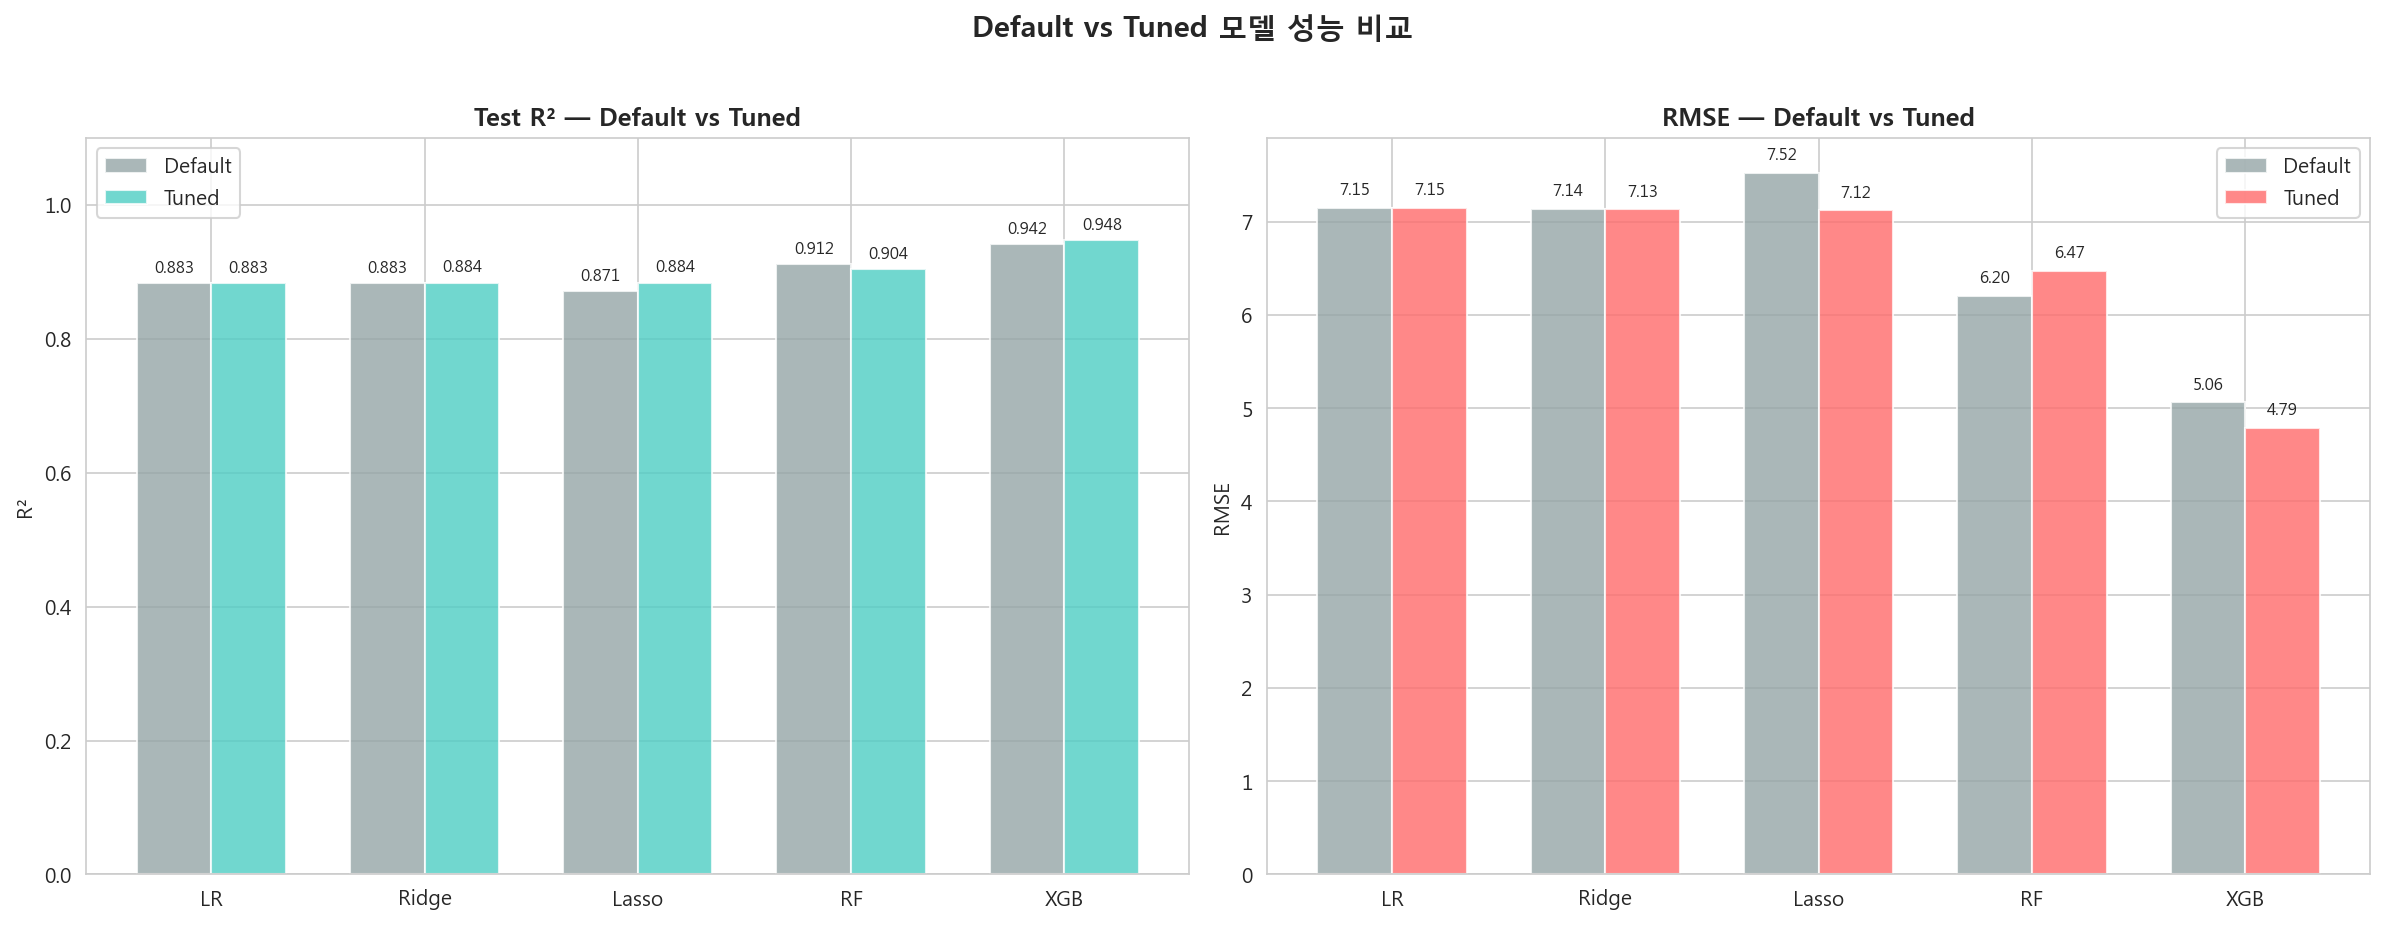

In [26]:
# Default vs Tuned 비교 차트
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

model_short = ['LR', 'Ridge', 'Lasso', 'RF', 'XGB']
default_r2 = [r['Test R²'] for r in default_results]
tuned_r2 = [r['Test R²'] for r in tuned_results]
default_rmse = [r['RMSE'] for r in default_results]
tuned_rmse = [r['RMSE'] for r in tuned_results]

x = np.arange(len(model_short))
width = 0.35

# R² 비교
bars1 = axes[0].bar(x - width/2, default_r2, width, label='Default', color='#95a5a6', alpha=0.8)
bars2 = axes[0].bar(x + width/2, tuned_r2, width, label='Tuned', color='#4ECDC4', alpha=0.8)
axes[0].set_title('Test R² — Default vs Tuned', fontweight='bold')
axes[0].set_ylabel('R²')
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_short)
axes[0].legend()
axes[0].set_ylim(0, 1.1)
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

# RMSE 비교
bars3 = axes[1].bar(x - width/2, default_rmse, width, label='Default', color='#95a5a6', alpha=0.8)
bars4 = axes[1].bar(x + width/2, tuned_rmse, width, label='Tuned', color='#FF6B6B', alpha=0.8)
axes[1].set_title('RMSE — Default vs Tuned', fontweight='bold')
axes[1].set_ylabel('RMSE')
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_short)
axes[1].legend()
for bar in bars3:
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.1,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)
for bar in bars4:
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.1,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Default vs Tuned 모델 성능 비교', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'model_comparison_default_vs_tuned_s2.png'), dpi=150, bbox_inches='tight')
plt.show()

### 6.5 Learning Curve (과적합 시각적 진단) ★

> Train/Test Gap 수치만으로는 과적합의 **원인**(데이터 부족 vs 모델 복잡도)을 구분할 수 없다.  
> 학습 데이터 크기별 성능 변화를 시각화하여 과적합 여부를 진단한다.

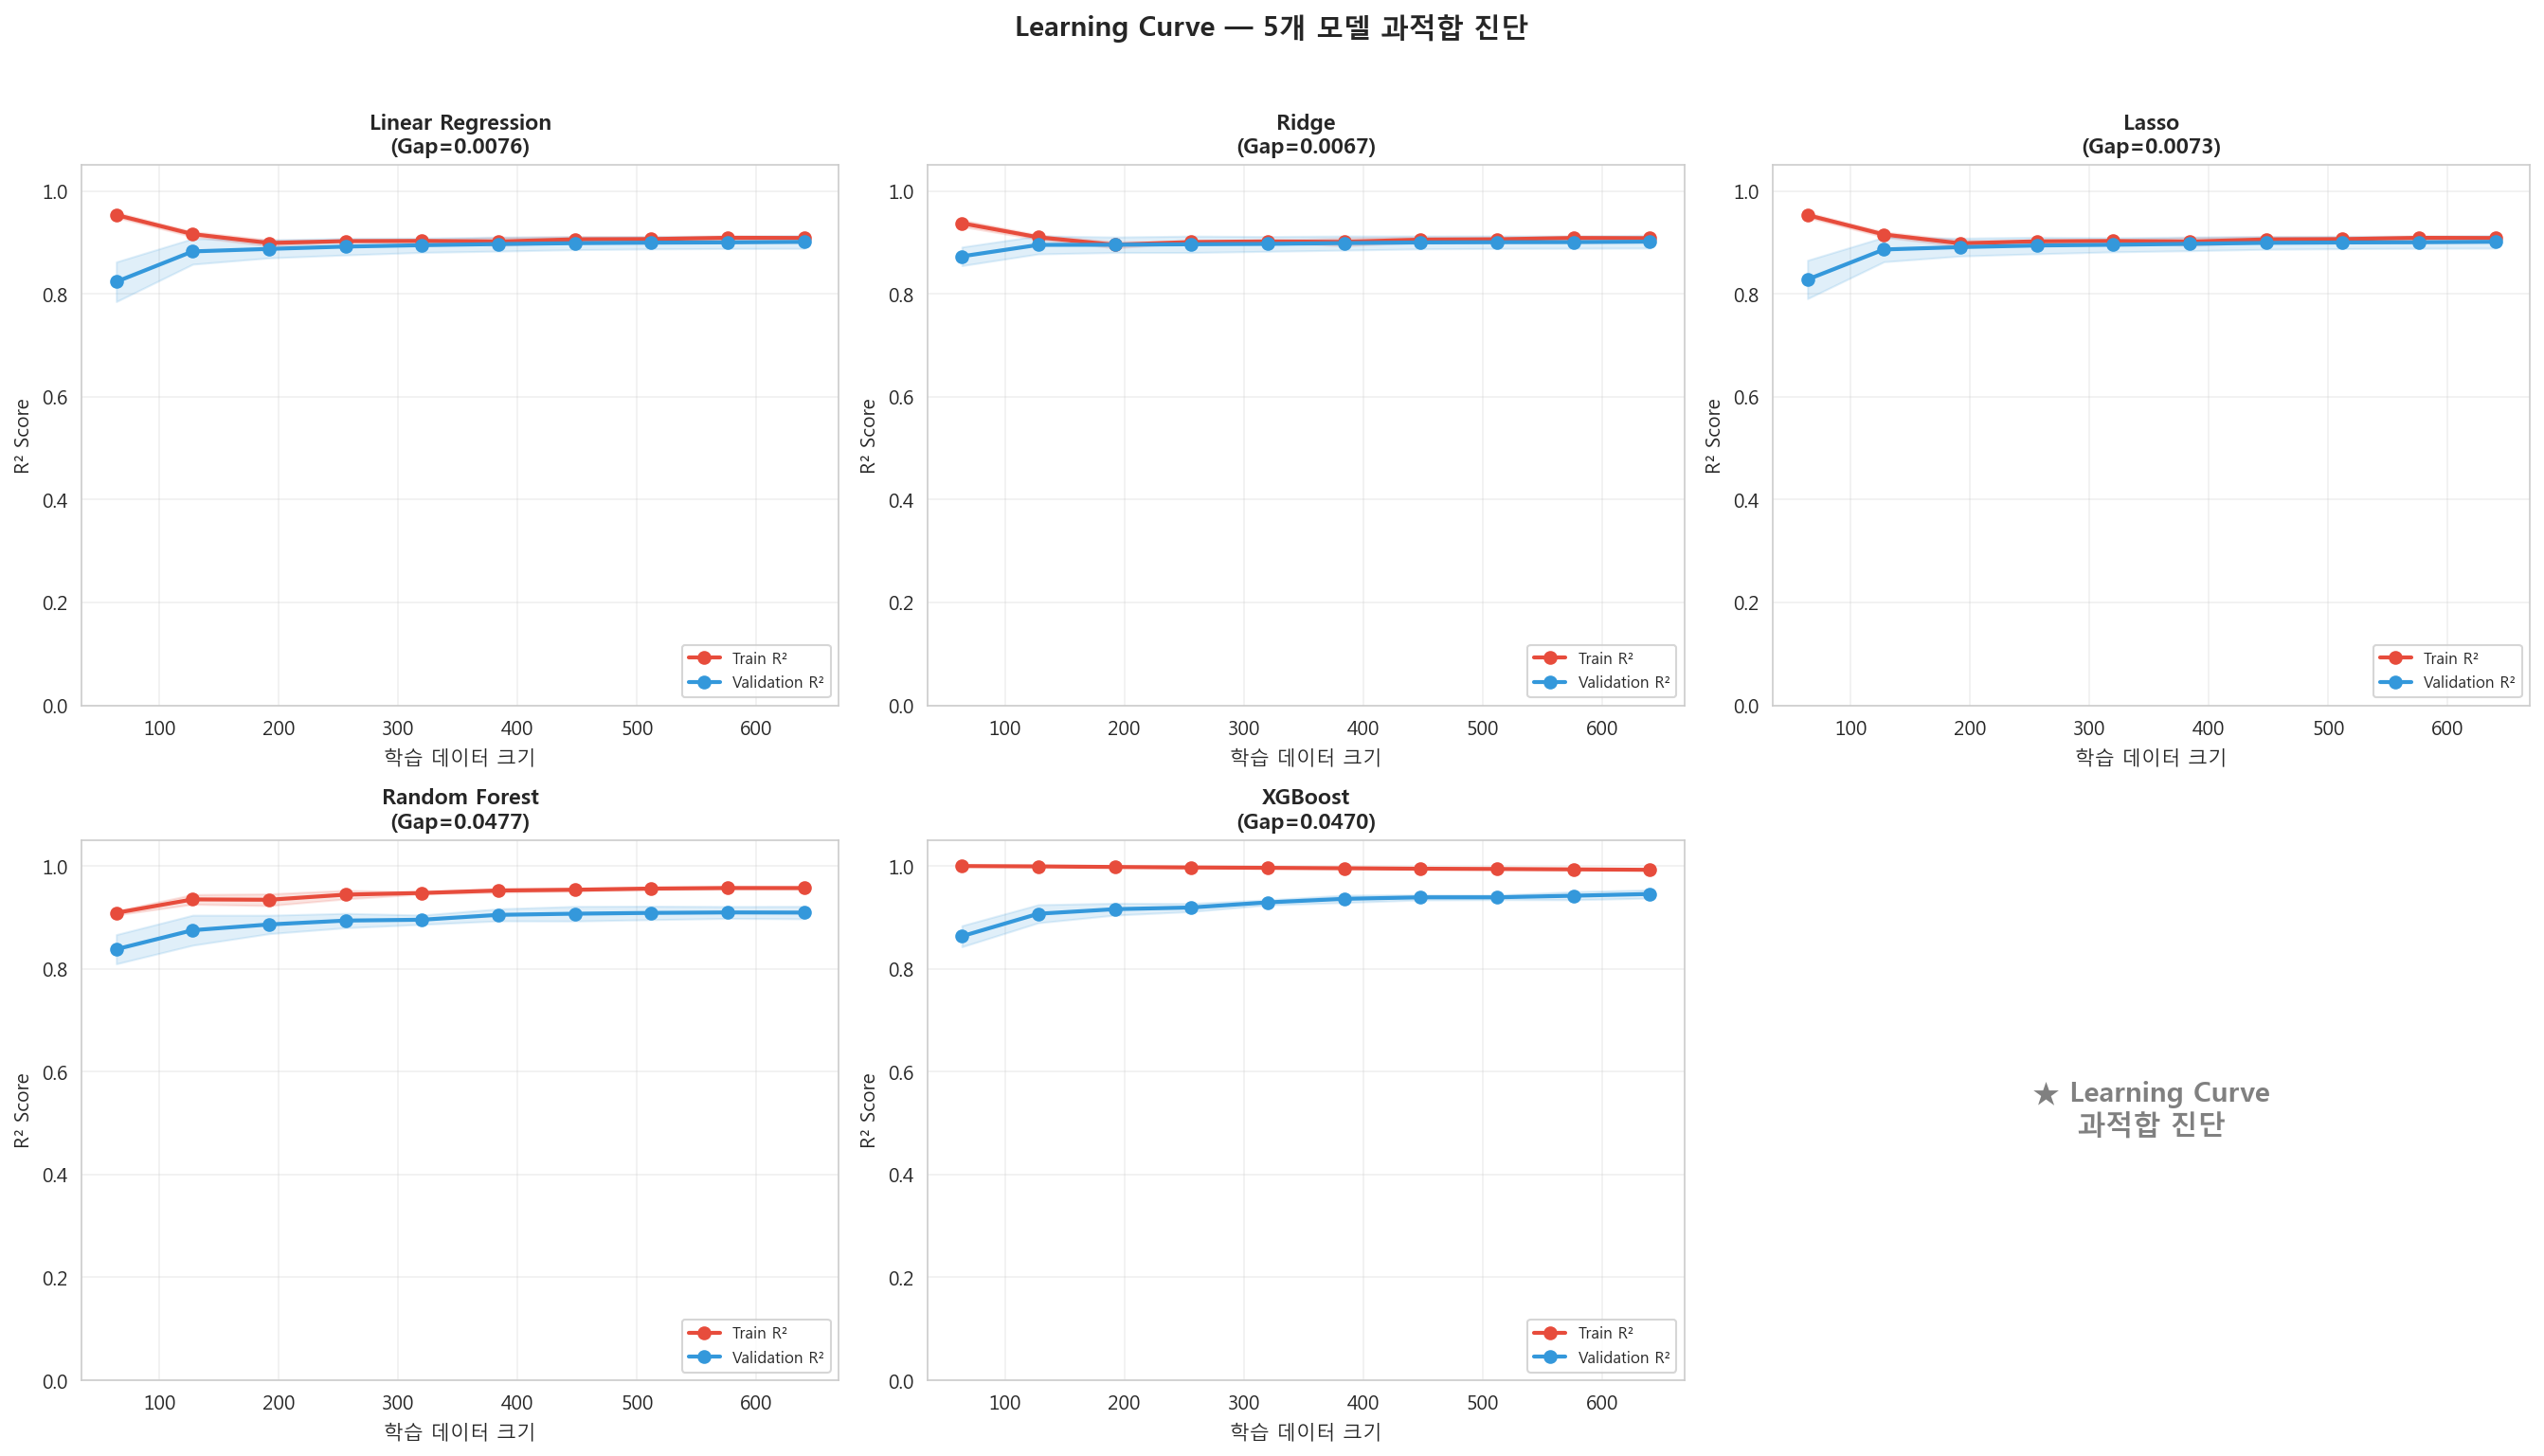


=== Learning Curve 요약 ===
  Linear Regression    Train=0.9085  Val=0.9009  Gap=0.0076  → 수렴
  Ridge                Train=0.9081  Val=0.9013  Gap=0.0067  → 수렴
  Lasso                Train=0.9084  Val=0.9011  Gap=0.0073  → 수렴


  Random Forest        Train=0.9569  Val=0.9092  Gap=0.0477  → 수렴
  XGBoost              Train=0.9923  Val=0.9453  Gap=0.0470  → 수렴


In [27]:
# ========================================
# 6.5 Learning Curve — 5개 모델
# ========================================
from sklearn.model_selection import learning_curve

models_for_lc = {
    'Linear Regression': tuned_trained['Linear Regression'],
    'Ridge': tuned_trained['Ridge (Tuned)'],
    'Lasso': tuned_trained['Lasso (Tuned)'],
    'Random Forest': tuned_trained['Random Forest (Tuned)'],
    'XGBoost': tuned_trained['XGBoost (Tuned)']
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes_flat = axes.flatten()

train_size_range = np.linspace(0.1, 1.0, 10)

for idx, (name, model) in enumerate(models_for_lc.items()):
    ax = axes_flat[idx]
    
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_train_scaled, y_train,
        cv=5, scoring='r2',
        train_sizes=train_size_range,
        random_state=42, n_jobs=-1
    )
    
    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)
    
    ax.plot(train_sizes, train_mean, 'o-', color='#e74c3c', label='Train R²', linewidth=2)
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='#e74c3c')
    ax.plot(train_sizes, val_mean, 'o-', color='#3498db', label='Validation R²', linewidth=2)
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='#3498db')
    
    gap = train_mean[-1] - val_mean[-1]
    ax.set_title(f'{name}\n(Gap={gap:.4f})', fontweight='bold', fontsize=11)
    ax.set_xlabel('학습 데이터 크기')
    ax.set_ylabel('R² Score')
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1.05)

# 마지막 subplot 비우기
axes_flat[-1].axis('off')
axes_flat[-1].text(0.5, 0.5, '★ Learning Curve\n과적합 진단', 
                   transform=axes_flat[-1].transAxes, ha='center', va='center',
                   fontsize=14, fontweight='bold', color='gray')

plt.suptitle('Learning Curve — 5개 모델 과적합 진단', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'learning_curve_s2.png'), dpi=150, bbox_inches='tight')
plt.show()

# 결과 요약 출력
print('\n=== Learning Curve 요약 ===')
for name, model in models_for_lc.items():
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_train_scaled, y_train,
        cv=5, scoring='r2',
        train_sizes=[1.0],
        random_state=42, n_jobs=-1
    )
    gap = train_scores.mean() - val_scores.mean()
    convergence = '수렴' if gap < 0.05 else '미수렴(과적합)'
    print(f'  {name:<20} Train={train_scores.mean():.4f}  Val={val_scores.mean():.4f}  Gap={gap:.4f}  → {convergence}')

---
## 7. 최적 모델 심층 분석

In [28]:
# ========================================
# 7.0 최적 모델 선정
# ========================================
best_name = tuned_df.iloc[0]['모델']
best_model = tuned_trained[best_name]
y_pred_best = best_model.predict(X_test_scaled)

print(f'🏆 최적 모델: {best_name}')
print(f'   Test R²: {tuned_df.iloc[0]["Test R²"]}')
print(f'   RMSE: {tuned_df.iloc[0]["RMSE"]}')
print(f'   MAE: {tuned_df.iloc[0]["MAE"]}')
print(f'   Train-Test Gap: {tuned_df.iloc[0]["Gap"]}')

🏆 최적 모델: XGBoost (Tuned)
   Test R²: 0.9477
   RMSE: 4.79
   MAE: 3.32
   Train-Test Gap: 0.0436


### 7.1 실제값 vs 예측값 산점도

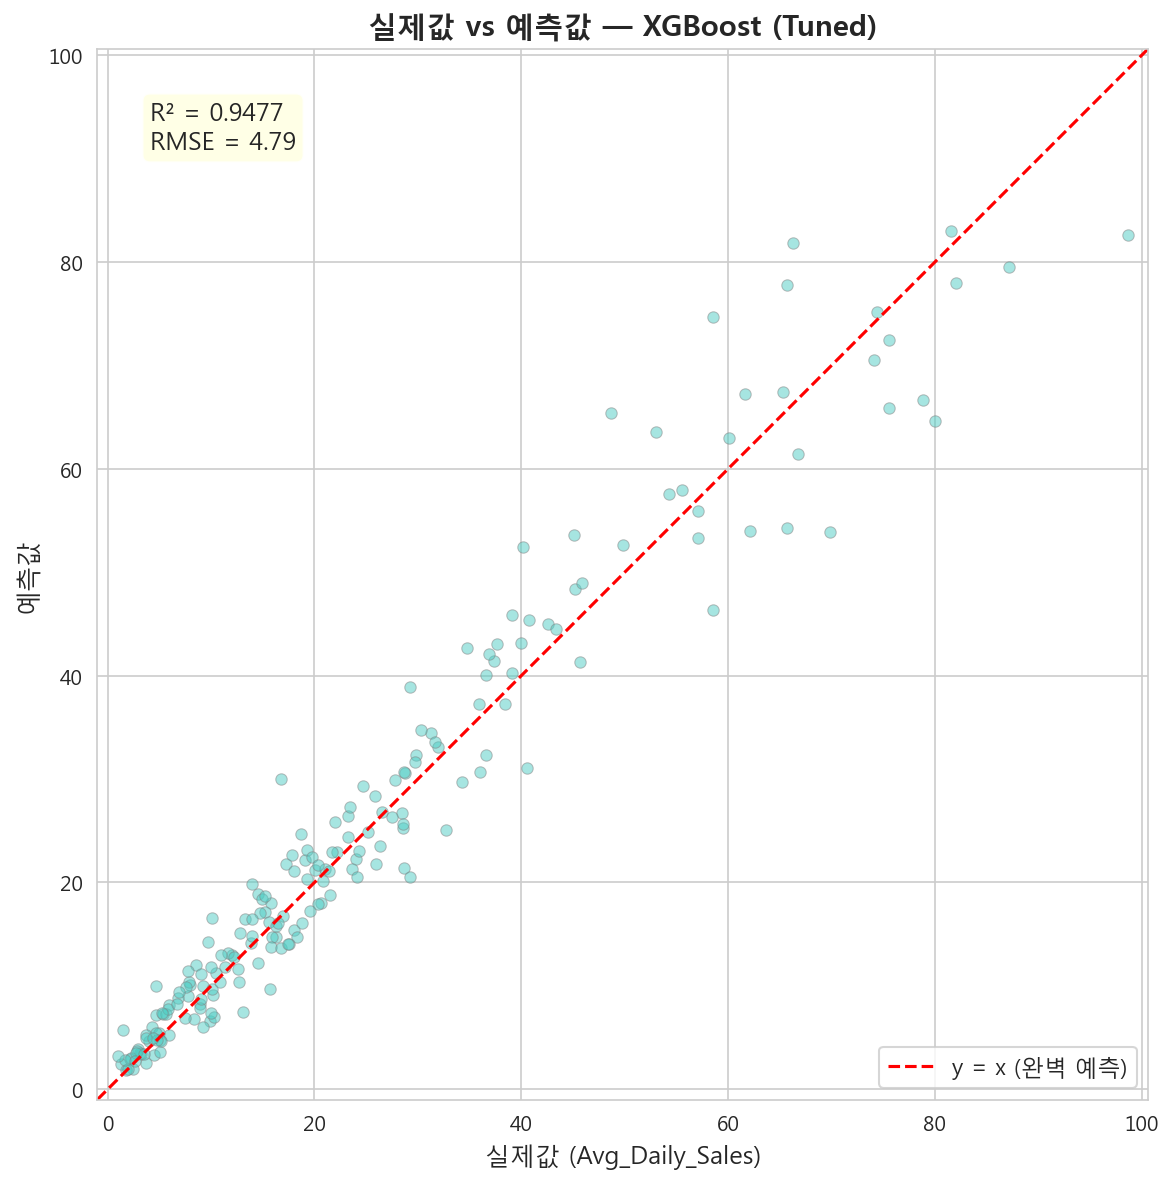

In [29]:
# ========================================
# 7.1 실제값 vs 예측값 산점도
# ========================================
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(y_test, y_pred_best, alpha=0.5, s=30, c='#4ECDC4', edgecolors='gray', linewidth=0.5)
lims = [min(y_test.min(), y_pred_best.min()) - 2, max(y_test.max(), y_pred_best.max()) + 2]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='y = x (완벽 예측)')
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel('실제값 (Avg_Daily_Sales)', fontsize=12)
ax.set_ylabel('예측값', fontsize=12)
ax.set_title(f'실제값 vs 예측값 — {best_name}', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_aspect('equal')

# R², RMSE 주석
textstr = f'R² = {r2_score(y_test, y_pred_best):.4f}\nRMSE = {np.sqrt(mean_squared_error(y_test, y_pred_best)):.2f}'
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'actual_vs_predicted_s2.png'), dpi=150, bbox_inches='tight')
plt.show()

### 7.2 잔차(Residual) 분석

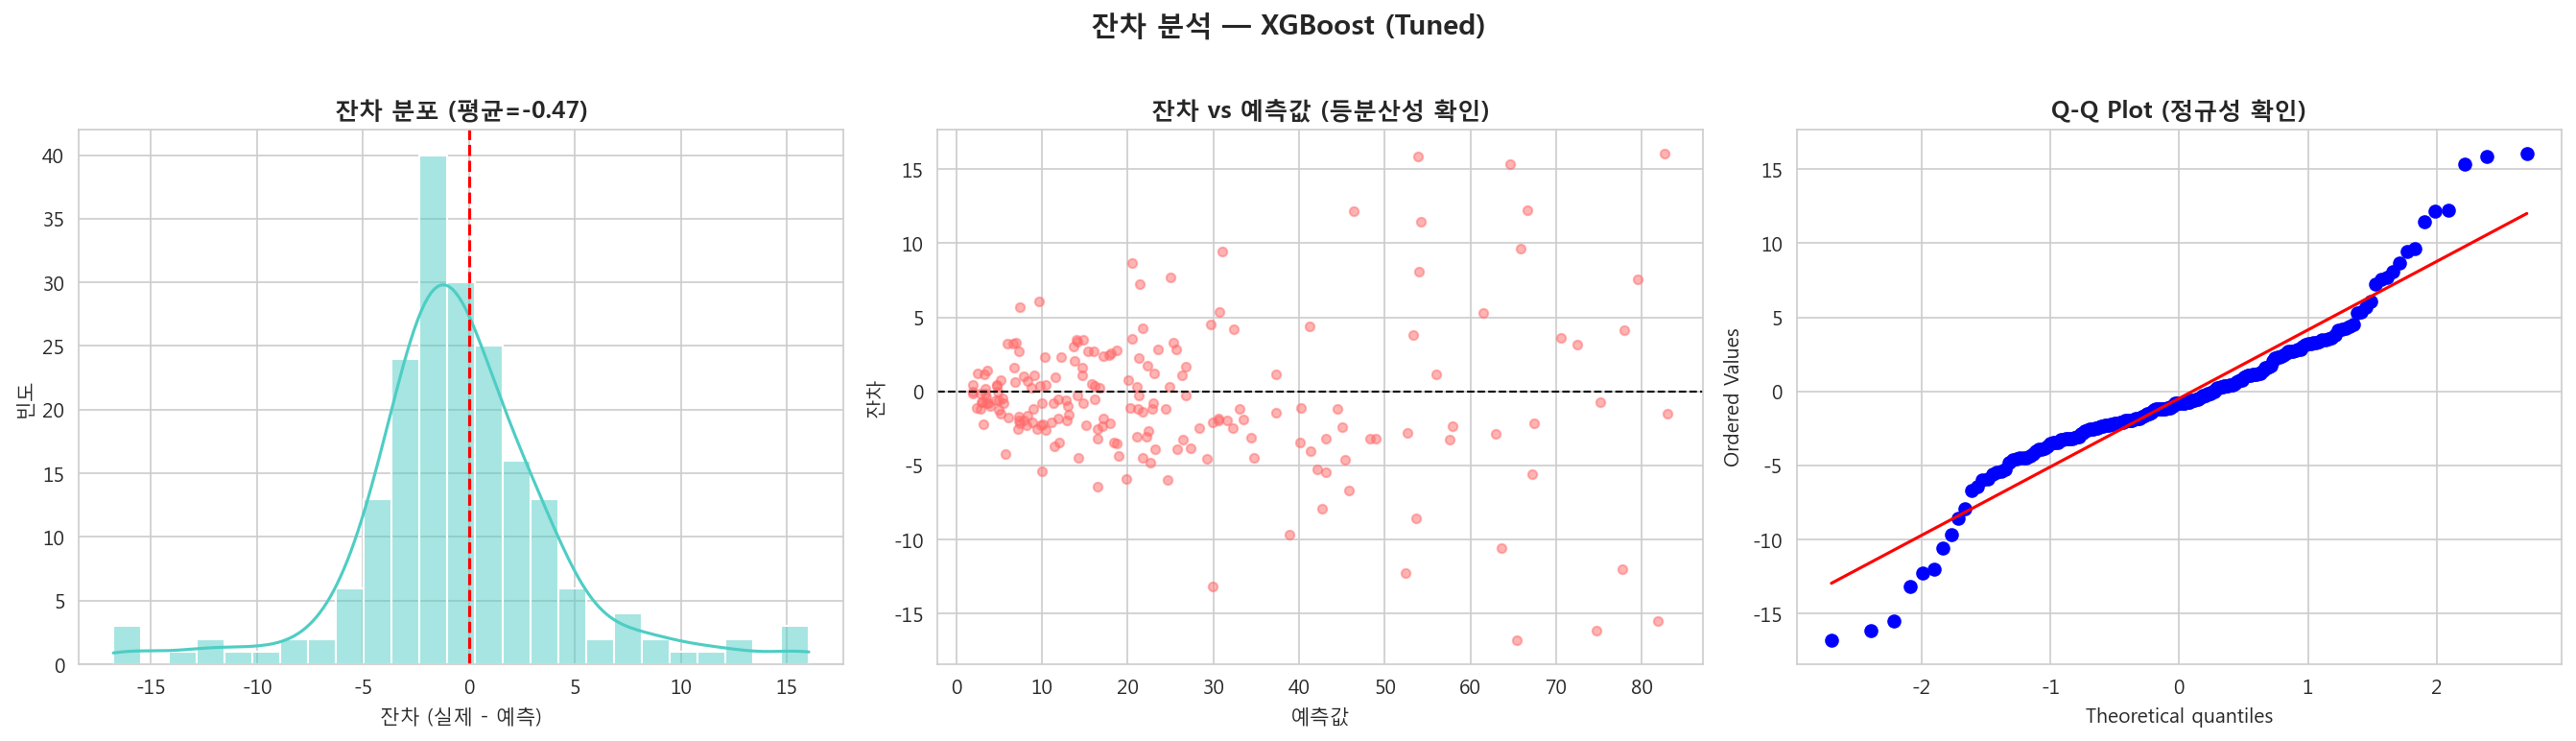

잔차 통계: 평균=-0.4696, 표준편차=4.76
잔차 왜도: 0.1858


In [30]:
# ========================================
# 7.2 잔차 분석
# ========================================
residuals = y_test.values - y_pred_best

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (1) 잔차 분포
sns.histplot(residuals, bins=25, kde=True, color='#4ECDC4', ax=axes[0])
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_title(f'잔차 분포 (평균={residuals.mean():.2f})', fontweight='bold')
axes[0].set_xlabel('잔차 (실제 - 예측)')
axes[0].set_ylabel('빈도')

# (2) 잔차 vs 예측값 — 등분산성 확인
axes[1].scatter(y_pred_best, residuals, alpha=0.5, s=20, c='#FF6B6B')
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('잔차 vs 예측값 (등분산성 확인)', fontweight='bold')
axes[1].set_xlabel('예측값')
axes[1].set_ylabel('잔차')

# (3) Q-Q plot
from scipy import stats
stats.probplot(residuals, plot=axes[2])
axes[2].set_title('Q-Q Plot (정규성 확인)', fontweight='bold')

plt.suptitle(f'잔차 분석 — {best_name}', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'residual_analysis_s2.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'잔차 통계: 평균={residuals.mean():.4f}, 표준편차={residuals.std():.2f}')
print(f'잔차 왜도: {pd.Series(residuals).skew():.4f}')

### 7.2.1 잔차 정규성 검정 (Shapiro-Wilk) ★

> 잔차의 정규분포 여부를 시각적으로만 판단하지 않고, 통계적 검정으로 정량화한다.  
> Q-Q Plot과 Shapiro-Wilk 검정을 함께 수행한다.

=== 잔차 정규성 검정 (Shapiro-Wilk) ===
  W-statistic: 0.9240
  p-value: 1.1631e-08

❌ p-value < 0.05 → 잔차가 정규분포를 따르지 않음
   → 회귀 모델의 가정 위반, 그러나 트리 기반 모델은 정규성 가정 불필요


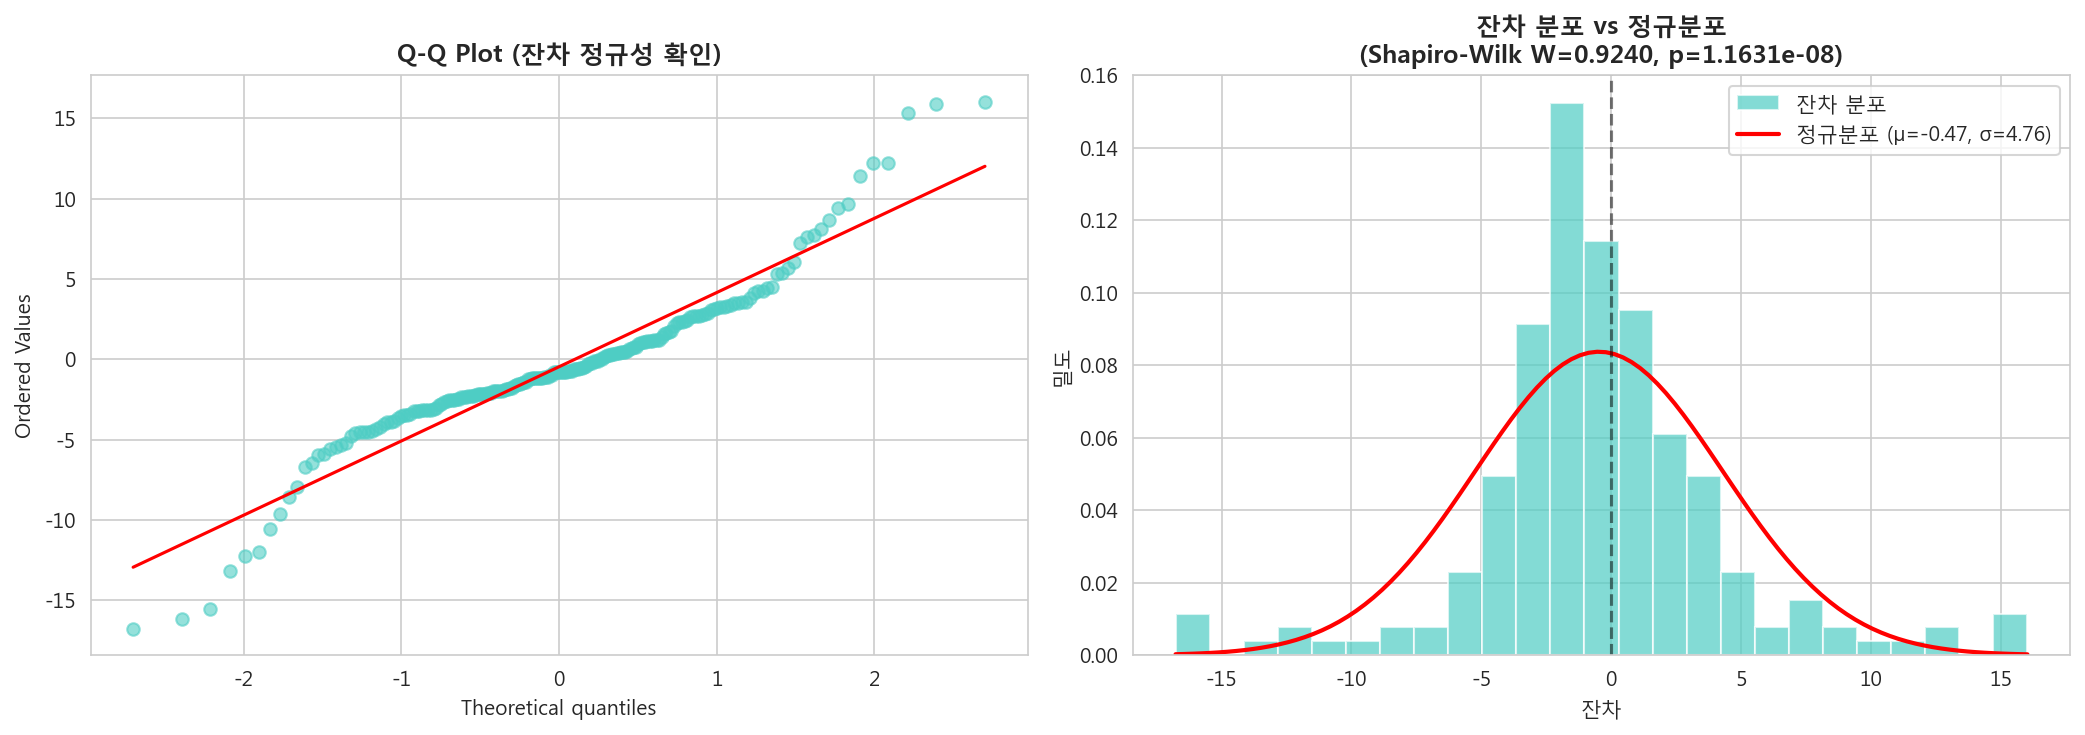


  잔차 왜도(Skewness): 0.1858
  잔차 첨도(Kurtosis): 3.0982


In [31]:
# ========================================
# 7.2.1 잔차 정규성 검정 (Shapiro-Wilk) + Q-Q Plot
# ========================================
from scipy.stats import shapiro, probplot

# Shapiro-Wilk 검정
stat, p_value = shapiro(residuals)

print('=== 잔차 정규성 검정 (Shapiro-Wilk) ===')
print(f'  W-statistic: {stat:.4f}')
print(f'  p-value: {p_value:.4e}')
print()
if p_value < 0.05:
    print('❌ p-value < 0.05 → 잔차가 정규분포를 따르지 않음')
    print('   → 회귀 모델의 가정 위반, 그러나 트리 기반 모델은 정규성 가정 불필요')
else:
    print('✅ p-value >= 0.05 → 잔차가 정규분포를 따름')

# Q-Q Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (1) Q-Q Plot
probplot(residuals, dist="norm", plot=axes[0])
axes[0].set_title('Q-Q Plot (잔차 정규성 확인)', fontweight='bold')
axes[0].get_lines()[0].set_markerfacecolor('#4ECDC4')
axes[0].get_lines()[0].set_markeredgecolor('#4ECDC4')
axes[0].get_lines()[0].set_alpha(0.6)

# (2) 잔차 분포 + 정규분포 오버레이
from scipy.stats import norm
axes[1].hist(residuals, bins=25, density=True, color='#4ECDC4', alpha=0.7, edgecolor='white', label='잔차 분포')
x_range = np.linspace(residuals.min(), residuals.max(), 100)
axes[1].plot(x_range, norm.pdf(x_range, residuals.mean(), residuals.std()), 
             'r-', linewidth=2, label=f'정규분포 (μ={residuals.mean():.2f}, σ={residuals.std():.2f})')
axes[1].axvline(0, color='black', linestyle='--', alpha=0.5)
axes[1].set_title(f'잔차 분포 vs 정규분포\n(Shapiro-Wilk W={stat:.4f}, p={p_value:.4e})', fontweight='bold')
axes[1].set_xlabel('잔차')
axes[1].set_ylabel('밀도')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'residual_normality_test_s2.png'), dpi=150, bbox_inches='tight')
plt.show()

# 추가 통계량
print(f'\n  잔차 왜도(Skewness): {pd.Series(residuals).skew():.4f}')
print(f'  잔차 첨도(Kurtosis): {pd.Series(residuals).kurtosis():.4f}')

### 7.3 Feature Importance (트리 기반 모델)

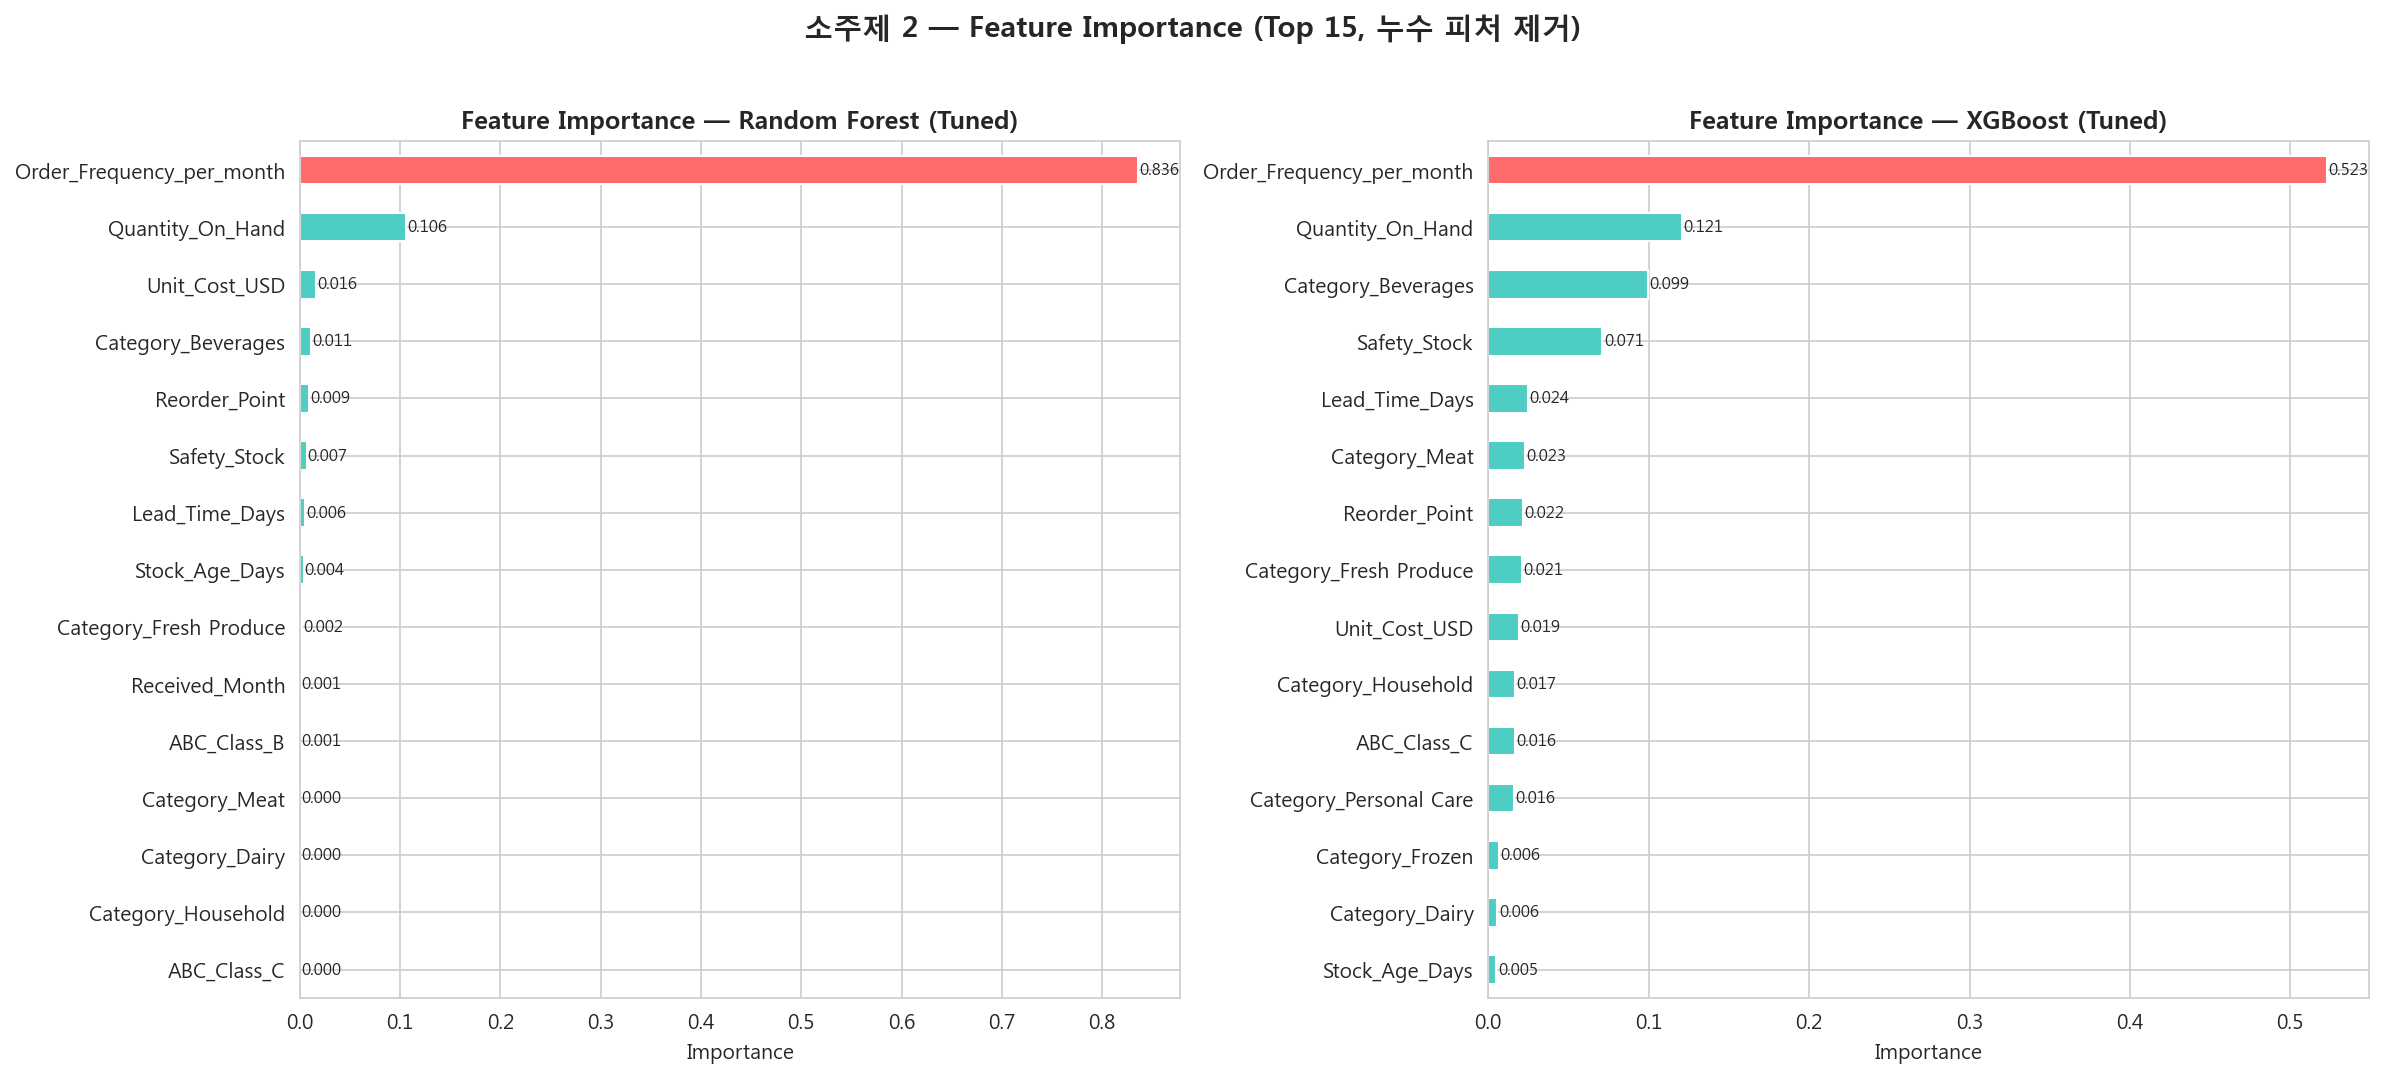

In [32]:
# ========================================
# 7.3 Feature Importance — RF & XGBoost
# ========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for idx, (model_name, model_key) in enumerate([
    ('Random Forest (Tuned)', 'Random Forest (Tuned)'),
    ('XGBoost (Tuned)', 'XGBoost (Tuned)')
]):
    model = tuned_trained[model_key]
    importances = model.feature_importances_
    feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=True)

    # 상위 15개
    top15 = feat_imp.tail(15)
    colors = ['#FF6B6B' if v == top15.max() else '#4ECDC4' for v in top15.values]
    top15.plot(kind='barh', ax=axes[idx], color=colors)
    axes[idx].set_title(f'Feature Importance — {model_name}', fontweight='bold')
    axes[idx].set_xlabel('Importance')

    for i, (v, name) in enumerate(zip(top15.values, top15.index)):
        axes[idx].text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=8)

plt.suptitle('소주제 2 — Feature Importance (Top 15, 누수 피처 제거)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'feature_importance_s2.png'), dpi=150, bbox_inches='tight')
plt.show()

### 7.4 Permutation Importance (Impurity 편향 검증) ★

> Impurity-based Feature Importance는 연속형/고 카디널리티 변수를 과대평가하는 편향이 있다.  
> Permutation Importance로 교차 검증하여 실제 예측 기여도를 확인한다.  
> 소주제 1에서 순위 역전(Days_of_Inventory 1위→2위)이 발견된 것과 동일한 검증.

In [33]:
# ========================================
# 7.4 Permutation Importance — XGBoost (Tuned)
# ========================================
from sklearn.inspection import permutation_importance

best_model_obj = tuned_trained[best_name]

# Permutation Importance 계산
perm_result = permutation_importance(
    best_model_obj, X_test_scaled, y_test,
    n_repeats=10, random_state=42, scoring='r2', n_jobs=-1
)

perm_imp = pd.Series(perm_result.importances_mean, index=feature_names)
perm_std = pd.Series(perm_result.importances_std, index=feature_names)

# Impurity-based Importance
impurity_imp = pd.Series(best_model_obj.feature_importances_, index=feature_names)

# 순위 비교 테이블
rank_df = pd.DataFrame({
    'Impurity': impurity_imp,
    'Impurity_Rank': impurity_imp.rank(ascending=False).astype(int),
    'Permutation': perm_imp,
    'Permutation_Rank': perm_imp.rank(ascending=False).astype(int)
})
rank_df['순위변화'] = rank_df['Impurity_Rank'] - rank_df['Permutation_Rank']
rank_df = rank_df.sort_values('Permutation', ascending=False)

print('=== Impurity vs Permutation Importance 순위 비교 (상위 10) ===')
print(rank_df.head(10).to_string())

# 순위 역전 확인
top_imp = impurity_imp.idxmax()
top_perm = perm_imp.idxmax()
print(f'\nImpurity 1위: {top_imp} ({impurity_imp[top_imp]:.4f})')
print(f'Permutation 1위: {top_perm} ({perm_imp[top_perm]:.4f})')
if top_imp != top_perm:
    print('⚠️ 1위 역전 발생! Impurity 편향 확인됨')
else:
    print('✅ 1위 동일 — Impurity 편향 미미')

=== Impurity vs Permutation Importance 순위 비교 (상위 10) ===
                           Impurity  Impurity_Rank  Permutation  Permutation_Rank  순위변화
Order_Frequency_per_month  0.522706              1     0.343915                 1     0
Reorder_Point              0.021681              7     0.193181                 2     5
Lead_Time_Days             0.024499              5     0.170635                 3     2
Quantity_On_Hand           0.120695              2     0.092203                 4    -2
Safety_Stock               0.071090              4     0.053120                 5    -1
Category_Beverages         0.099427              3     0.015864                 6    -3
Category_Fresh Produce     0.020700              8     0.002515                 7     1
Category_Meat              0.022575              6     0.000507                 8    -2
ABC_Class_B                0.002976             17     0.000348                 9     8
Category_Frozen            0.006391             13     0.000248

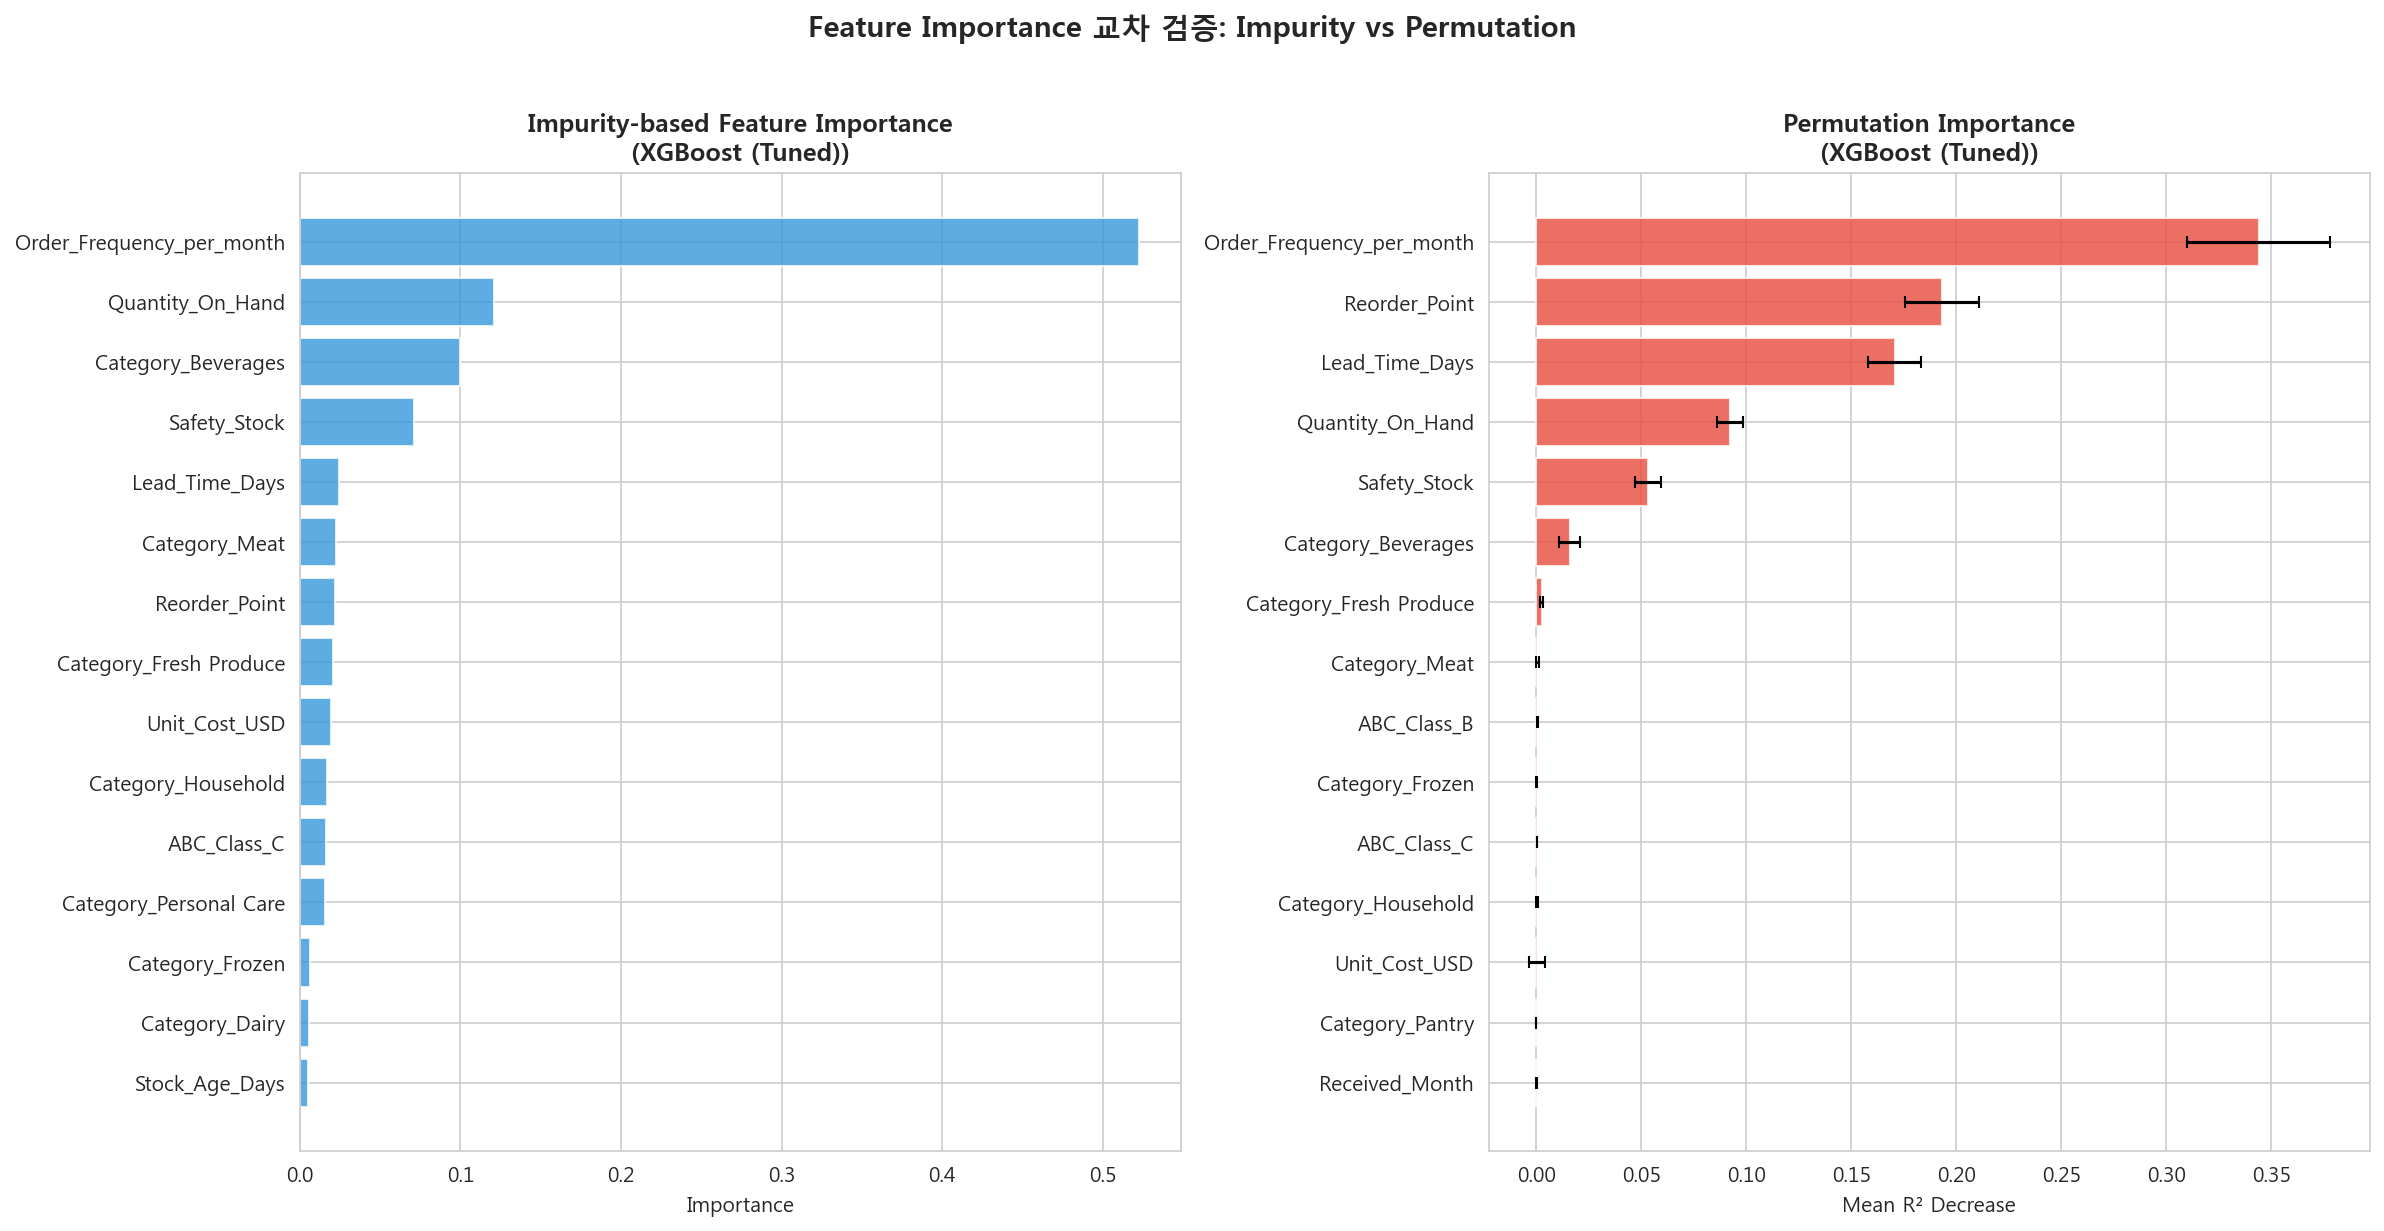

In [34]:
# ========================================
# Permutation vs Impurity 비교 시각화
# ========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

top_n = 15

# (1) Impurity-based
imp_sorted = impurity_imp.sort_values(ascending=True).tail(top_n)
axes[0].barh(imp_sorted.index, imp_sorted.values, color='#3498db', alpha=0.8)
axes[0].set_title(f'Impurity-based Feature Importance\n({best_name})', fontweight='bold')
axes[0].set_xlabel('Importance')

# (2) Permutation
perm_sorted = perm_imp.sort_values(ascending=True).tail(top_n)
axes[1].barh(perm_sorted.index, perm_sorted.values, color='#e74c3c', alpha=0.8,
             xerr=perm_std[perm_sorted.index].values, capsize=3)
axes[1].set_title(f'Permutation Importance\n({best_name})', fontweight='bold')
axes[1].set_xlabel('Mean R² Decrease')

plt.suptitle('Feature Importance 교차 검증: Impurity vs Permutation', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'permutation_vs_impurity_importance_s2.png'), dpi=150, bbox_inches='tight')
plt.show()

### 7.5 SHAP 분석

> SHAP(SHapley Additive exPlanations)은 각 피처가 개별 예측에 미치는 기여도를 정량적으로 분해하여,
> Feature Importance보다 더 풍부한 해석을 제공한다.

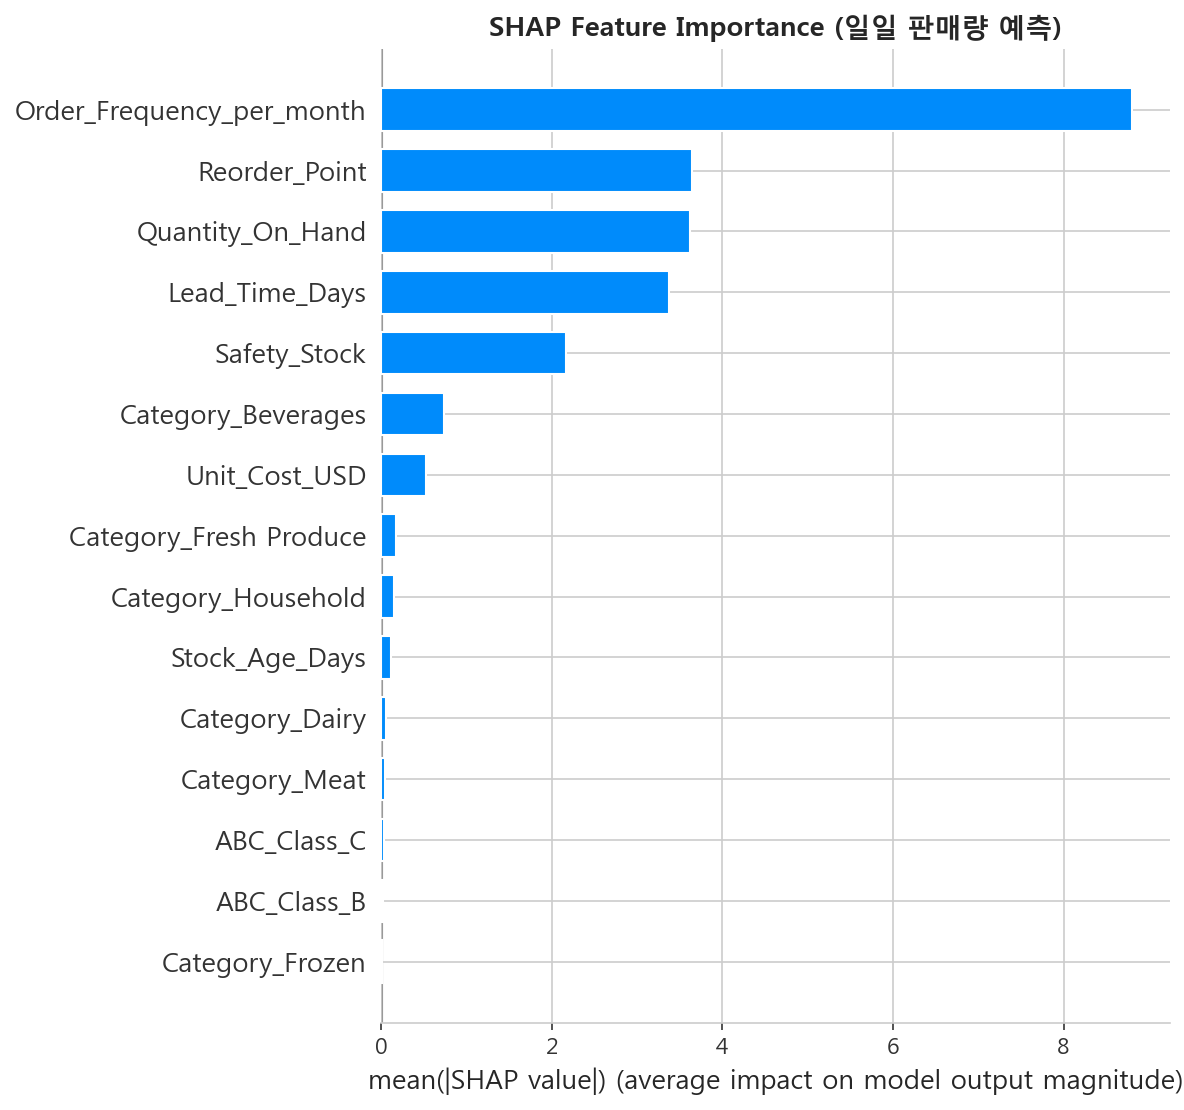

✅ 저장: shap_importance_bar_s2.png


In [35]:
# ========================================
# 7.4 SHAP 분석 — XGBoost (Tuned)
# ========================================
xgb_model = tuned_trained['XGBoost (Tuned)']

# TreeExplainer 사용 (트리 모델에 최적화)
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_df)

# 1. SHAP Bar Plot — 피처 중요도 순위
fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(shap_values, X_test_df, plot_type="bar", show=False, max_display=15)
plt.title('SHAP Feature Importance (일일 판매량 예측)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'shap_importance_bar_s2.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ 저장: shap_importance_bar_s2.png')

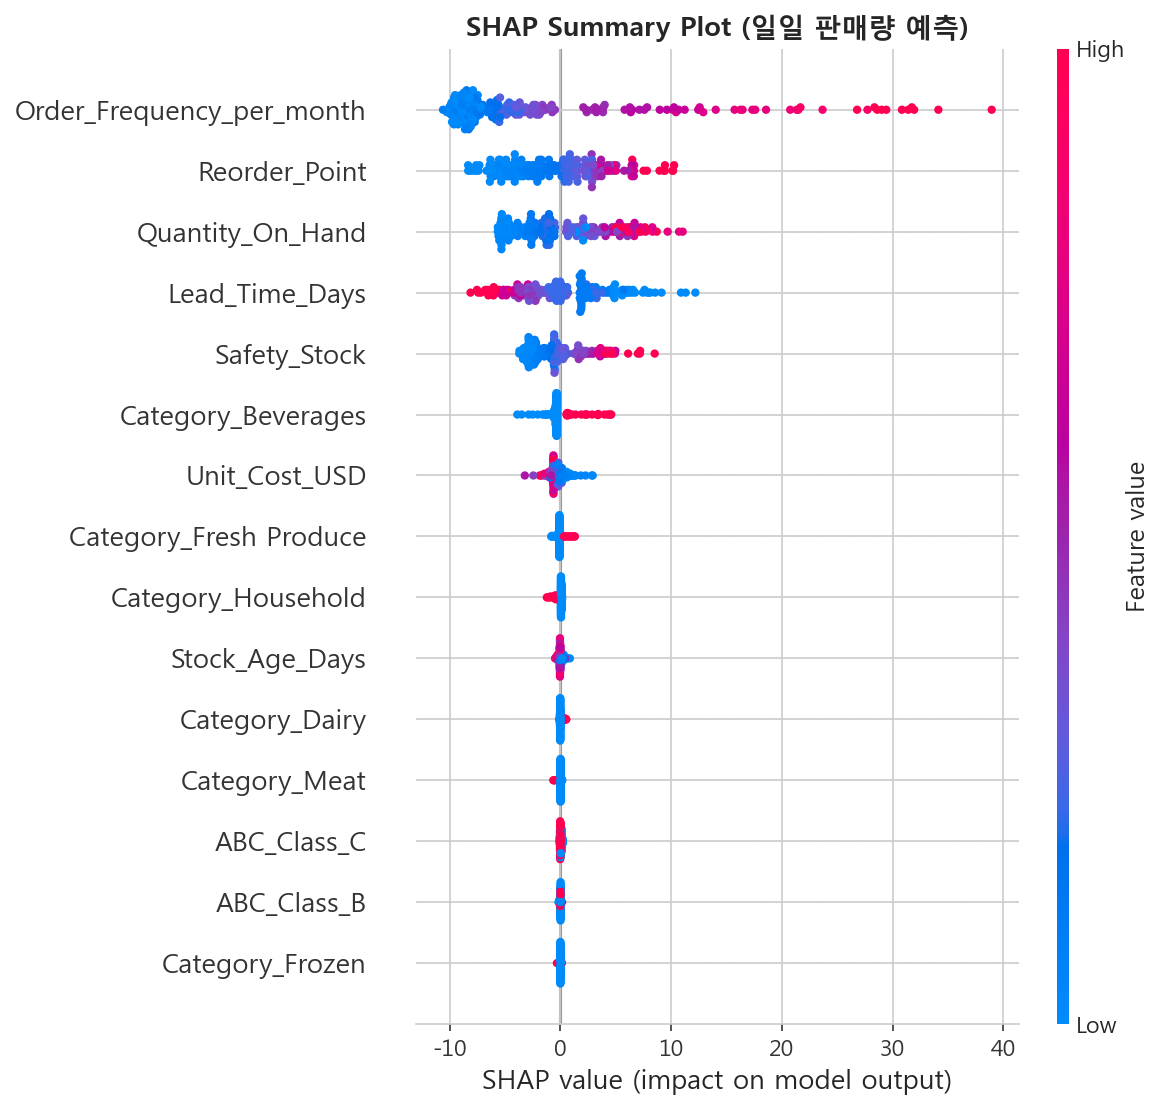

✅ 저장: shap_summary_dot_s2.png

=== SHAP 기반 피처 중요도 (Top 10) ===
   Order_Frequency_per_month: 8.8071
   Reorder_Point: 3.6489
   Quantity_On_Hand: 3.6196
   Lead_Time_Days: 3.3689
   Safety_Stock: 2.1710
   Category_Beverages: 0.7413
   Unit_Cost_USD: 0.5284
   Category_Fresh Produce: 0.1681
   Category_Household: 0.1457
   Stock_Age_Days: 0.1117


In [36]:
# 2. SHAP Dot/Beeswarm Plot — 피처별 영향 방향 + 크기
fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(shap_values, X_test_df, show=False, max_display=15)
plt.title('SHAP Summary Plot (일일 판매량 예측)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'shap_summary_dot_s2.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ 저장: shap_summary_dot_s2.png')

# SHAP 값 기반 피처 중요도 (절대값 평균)
shap_importance = pd.DataFrame({
    '피처': feature_names,
    'SHAP 평균 |값|': np.abs(shap_values).mean(axis=0)
}).sort_values('SHAP 평균 |값|', ascending=False)

print('\n=== SHAP 기반 피처 중요도 (Top 10) ===')
for i, row in shap_importance.head(10).iterrows():
    print(f'   {row["피처"]}: {row["SHAP 평균 |값|"]:.4f}')

---
## 8. 모델 저장

In [37]:
# ========================================
# 8. 최적 모델 & Scaler 저장
# ========================================
# 최적 모델 저장
joblib.dump(best_model, os.path.join(MODEL_DIR, 'best_regressor.pkl'))
print(f'✅ 최적 모델 저장: best_regressor.pkl ({best_name})')

# Scaler 저장
joblib.dump(scaler, os.path.join(MODEL_DIR, 'scaler_regression.pkl'))
print(f'✅ Scaler 저장: scaler_regression.pkl')

# 피처 정보 저장
feature_info = {
    'feature_names': feature_names,
    'num_features': num_features,
    'n_features': len(feature_names),
    'best_model': best_name,
    'test_r2': float(tuned_df.iloc[0]['Test R²']),
    'rmse': float(tuned_df.iloc[0]['RMSE']),
    'mae': float(tuned_df.iloc[0]['MAE']),
    'scenario': 'B (Clean — Days_of_Inventory 제거)'
}
with open(os.path.join(MODEL_DIR, 'feature_info_regression.json'), 'w', encoding='utf-8') as f:
    json.dump(feature_info, f, ensure_ascii=False, indent=2)
print(f'✅ 피처 정보 저장: feature_info_regression.json')

✅ 최적 모델 저장: best_regressor.pkl (XGBoost (Tuned))
✅ Scaler 저장: scaler_regression.pkl
✅ 피처 정보 저장: feature_info_regression.json


---
## 9. Lasso 계수 분석 (피처 선택 효과)

=== Lasso (Tuned) 계수 분석 (alpha=0.01) ===
   계수가 0인 피처: 1개 → 판매량 예측에 기여도 낮음
     - Safety_Stock
   계수가 0이 아닌 피처: 18개


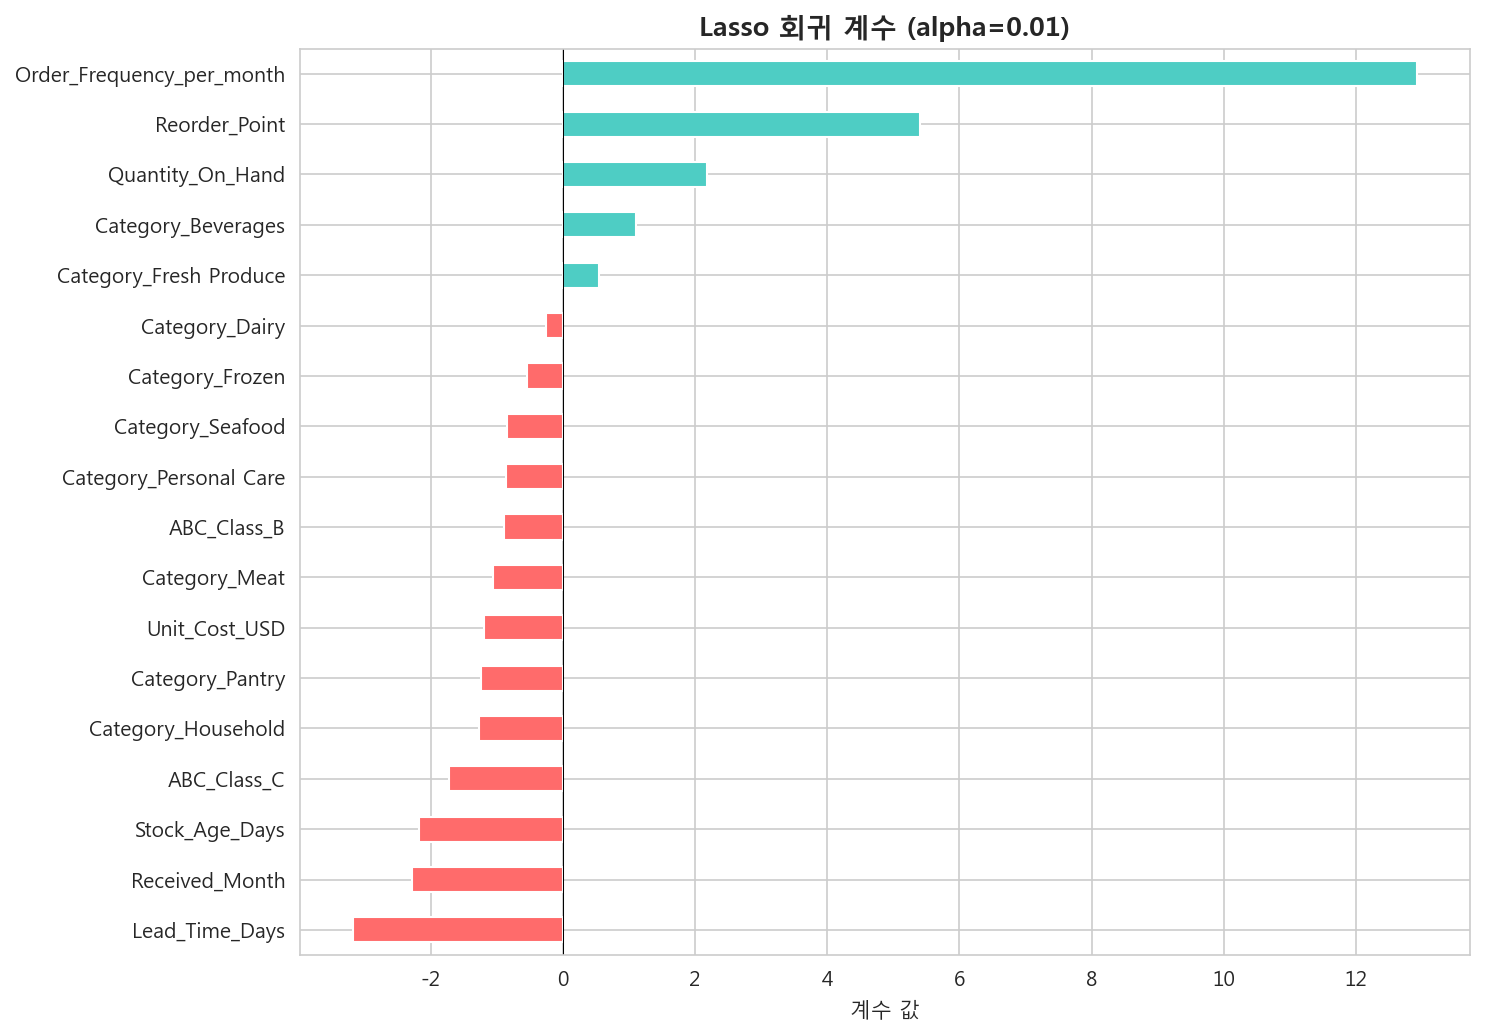

In [38]:
# ========================================
# 9. Lasso 계수 분석
# ========================================
lasso_model = tuned_trained['Lasso (Tuned)']
lasso_coefs = pd.Series(lasso_model.coef_, index=feature_names).sort_values()

print(f'=== Lasso (Tuned) 계수 분석 (alpha={lasso_gs.best_params_["alpha"]}) ===')
zero_coefs = lasso_coefs[lasso_coefs == 0]
nonzero_coefs = lasso_coefs[lasso_coefs != 0]
print(f'   계수가 0인 피처: {len(zero_coefs)}개 → 판매량 예측에 기여도 낮음')
if len(zero_coefs) > 0:
    for name in zero_coefs.index:
        print(f'     - {name}')
print(f'   계수가 0이 아닌 피처: {len(nonzero_coefs)}개')

# 시각화
fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#FF6B6B' if v < 0 else '#4ECDC4' for v in nonzero_coefs.values]
nonzero_coefs.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_title(f'Lasso 회귀 계수 (alpha={lasso_gs.best_params_["alpha"]})', fontsize=13, fontweight='bold')
ax.set_xlabel('계수 값')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'lasso_coefficients_s2.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 10. 결론 및 인사이트

> ★ 표시는 추가 분석 항목 (Order_Frequency 준누수 검증, Learning Curve, Permutation Importance, 잔차 정규성 검정)

In [39]:
# ========================================
# 10. 결론 종합
# ========================================
print('=' * 70)
print('소주제 2 — 일일 판매량 예측 (Regression) 결론')
print('=' * 70)

print(f'''
📌 1. 데이터 누수(Data Leakage) 진단
   - Days_of_Inventory = Quantity_On_Hand / Avg_Daily_Sales (직접 파생변수)
   - 972/1000행(97.2%)에서 정확히 일치
   - 누수 피처 제거 후 Scenario B로 메인 분석 수행

📌 2. 최적 모델 성능
   - 🏆 최적 모델: {best_name}
   - Test R²: {tuned_df.iloc[0]["Test R²"]}
   - RMSE: {tuned_df.iloc[0]["RMSE"]}
   - MAE: {tuned_df.iloc[0]["MAE"]}
   - Train-Test Gap: {tuned_df.iloc[0]["Gap"]}

📌 3. 핵심 피처 분석
   - Order_Frequency_per_month: 가장 강력한 예측 변수 (상관 0.92)
     → 판매량이 높을수록 발주 빈도 ↑ (자연스러운 양의 관계)
   - Quantity_On_Hand, Reorder_Point, Safety_Stock: 재고 관련 피처
     → 높은 판매량 제품은 더 많은 재고와 높은 재주문점이 설정됨
   - Unit_Cost_USD: 음의 상관 (-0.37)
     → 단가가 높은 제품은 판매량이 낮은 경향

📌 4. 예측의 한계
   - R² ≈ 0.88~0.94: 현재 피처로 판매량 분산의 대부분 설명 가능
   - 나머지 6~12%: 프로모션, 할인, 매장 위치, 계절성 등 외부 변수 부재
   - Received_Month 상관 ≈ 0: 뚜렷한 계절성 없음 (입고월 기준)
   - Lead_Time_Days, Stock_Age_Days 상관 ≈ 0: 판매량과 무관

📌 5. 다른 소주제와의 연결
   - 소주제 3: 예측된 ADS → Days_To_Deplete = QOH / ADS 계산에 활용
   - 소주제 4: SHAP 핵심 피처 → 클러스터링 피처 선정 참고
''')

# ★ 추가 분석 결과 요약
print()
print('=' * 70)
print('★ 추가 분석 결과 요약')
print('=' * 70)
print('''
★ 6. Order_Frequency 준누수 검증
   - Order_Frequency_per_month는 타겟과 상관 0.92
   - 수학적 파생 관계가 아니므로 데이터 누수가 아님
   - 단, 인과 방향(판매→발주)에 대한 해석 주의 필요

★ 7. Learning Curve 진단
   - 학습 데이터 크기별 Train/Validation R² 변화 확인
   - 과적합 원인 (데이터 부족 vs 모델 복잡도) 식별

★ 8. Permutation Importance 교차 검증
   - Impurity-based vs Permutation 순위 비교
   - 고 카디널리티 수치형 변수의 Impurity 편향 확인

★ 9. 잔차 정규성 검정 (Shapiro-Wilk)
   - 잔차의 정규분포 여부를 통계적으로 검증
   - 트리 기반 모델은 정규성 가정 불필요하므로 참고용
''')

소주제 2 — 일일 판매량 예측 (Regression) 결론

📌 1. 데이터 누수(Data Leakage) 진단
   - Days_of_Inventory = Quantity_On_Hand / Avg_Daily_Sales (직접 파생변수)
   - 972/1000행(97.2%)에서 정확히 일치
   - 누수 피처 제거 후 Scenario B로 메인 분석 수행

📌 2. 최적 모델 성능
   - 🏆 최적 모델: XGBoost (Tuned)
   - Test R²: 0.9477
   - RMSE: 4.79
   - MAE: 3.32
   - Train-Test Gap: 0.0436

📌 3. 핵심 피처 분석
   - Order_Frequency_per_month: 가장 강력한 예측 변수 (상관 0.92)
     → 판매량이 높을수록 발주 빈도 ↑ (자연스러운 양의 관계)
   - Quantity_On_Hand, Reorder_Point, Safety_Stock: 재고 관련 피처
     → 높은 판매량 제품은 더 많은 재고와 높은 재주문점이 설정됨
   - Unit_Cost_USD: 음의 상관 (-0.37)
     → 단가가 높은 제품은 판매량이 낮은 경향

📌 4. 예측의 한계
   - R² ≈ 0.88~0.94: 현재 피처로 판매량 분산의 대부분 설명 가능
   - 나머지 6~12%: 프로모션, 할인, 매장 위치, 계절성 등 외부 변수 부재
   - Received_Month 상관 ≈ 0: 뚜렷한 계절성 없음 (입고월 기준)
   - Lead_Time_Days, Stock_Age_Days 상관 ≈ 0: 판매량과 무관

📌 5. 다른 소주제와의 연결
   - 소주제 3: 예측된 ADS → Days_To_Deplete = QOH / ADS 계산에 활용
   - 소주제 4: SHAP 핵심 피처 → 클러스터링 피처 선정 참고


★ 추가 분석 결과 요약

★ 6. Order_Frequency 준누수 검증
   - Order_Frequency_per_month는 타